# Spectral and spatial-spectral deep learning for hyperspectral imaging

In this notebook we predict the mean fat content of pork bellies from near-infrared hyperspectral images with five different models: Partial Least Squares (PLS), a Multilayer Perceptron (MLP), a 1D ResNet, a 2D ResNet and a Vision Transformer (ViT). The tutorial covers the data, the theory behind each model, the full training pipeline, and a side-by-side comparison of the results.

Based on the research of Ole-Christian Galbo Engstrøm (ocge@foss.dk)
Reference study: Engstrøm et al. (2025), Journal of Chemometrics 39:e70041, https://doi.org/10.1002/cem.70041<br>

## The story of this notebook

Imagine a pork belly arriving at a processing plant. The plant wants to know how fat it is, because fat content decides the price and what the belly will be used for. The traditional answer comes from the chemistry lab: mince the whole belly, extract the fat and weigh it. This is accurate, but it is slow, expensive and it destroys the product.

A hyperspectral camera offers a different route. Every pixel of a hyperspectral image holds a full spectrum, and near-infrared light interacts with the chemical bonds of fat, water and protein. If we can teach a model to translate what the camera sees into the number the lab would report, we get a fast and non-destructive measurement.

The dataset we use contains 182 pork bellies. Each belly was cut into five slices, every slice was imaged with a VIS-NIR hyperspectral camera, and the whole belly was then analysed chemically. So we have many images, but only one reference number (`Fat_chem`, in percent) per belly.

There are two fundamentally different ways to look at such data, and this notebook walks through both:

1. The spectral view. We average all meat pixels of all slices into one mean spectrum per belly. Every belly becomes a single curve with 124 numbers, and we regress fat content on that curve. This is the classical chemometrics recipe.
2. The spatial-spectral view. We keep the images. A model now sees where things are, not only what the average looks like, and has to learn by itself how to summarise thousands of pixels into one prediction.

We will climb a ladder of five models, each one adding a new idea:

| Step | Model | Input | New idea it brings |
|---|---|---|---|
| 1 | PLS | mean spectrum (124 values) | a linear model built on a few latent variables |
| 2 | MLP | mean spectrum | non-linearity, every wavelength connected to every neuron |
| 3 | 1D ResNet | mean spectrum | convolutions that slide along the wavelength axis, residual connections |
| 4 | 2D ResNet | image slices (62 bands x H x W) | convolutions that slide over the image, a 3D spectral front-end |
| 5 | ViT | image slices | attention between image patches, global context from the first layer |

## 0) Setup for Google Colab

This setup cell installs the one package that is not part of the standard Colab image:

- `ikpls`, a fast implementation of the Improved Kernel PLS algorithm, written by Ole-Christian Galbo Engstrøm.

In [1]:
## Install the packages that are missing in Google Colab
!pip install -q ikpls

### Getting the course data

The full image dataset is about 207 GB, far too large to share. The course folder therefore contains:

- the metadata table and the mean spectra of all 182 bellies (less than 1 MB). This is all the spectral models need, so PLS, the MLP and the 1D ResNet are trained from scratch in this notebook;
- the images of two test bellies only, a lean one and a fat one;
- the pre-trained weights of the four neural models, trained beforehand on the full dataset.

The folder layout  for the lab is:

```
end2end/
    red_data_with_splits.csv          one row per belly: meat_id, Fat_chem, split, ...
    spectra_mean.npy, spectra_std.npy precomputed input statistics (optional, used as a cross-check)
    target_mean.npy, target_std.npy   precomputed target statistics (optional, used as a cross-check)
    meat_id_mean_spectra/absorbance/  {meat_id}.npy, one mean spectrum (300 channels) per belly
    HSI_binned_images/                two example bellies, all slices
        images/        {meat_id}-{slice}.npy   uint16, shape (62, H, W)
        masks/         {meat_id}-{slice}.npy   uint8,  shape (1, H, W)
        quant_biases/  {meat_id}-{slice}.npy   float32 scalar
        quant_scales/  {meat_id}-{slice}.npy   float32 scalar
    
    mlp/best_weights.pt, resnet1d/best_weights.pt, resnet2d/best_weights.pt, vit/best_weights.pt (pretrained model weights)
```

The pre-trained weights were produced by training the models defined in this notebook on the full dataset.

Your own training runs (the spectral models) are written to `RUN_DIR`.

In [2]:
from pathlib import Path

## Mount Google Drive when running in Colab (outside Colab this is simply skipped)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import shutil

## ------------------------------------------------------------------------------
## USER SETTINGS
## ------------------------------------------------------------------------------
## The shortcut to the shared course folder in your Google Drive
SHARED_DATA = Path('/content/drive/MyDrive/data/end2end')
## Your own training runs (small files, kept in your Drive)
RUN_DIR = Path('.')
## Copy the course data to the local disk of the Colab machine (fast, does not use your Drive quota)
COPY_TO_LOCAL_DISK = True
LOCAL_DATA = Path('data/end2end')

## Where do the GPU CHECKPOINT cells take their weights from?
##   'auto'       -> your own run if it exists, otherwise the pre-trained weights
##   'own'        -> only your own run (error if you did not train the model)
##   'pretrained' -> always the pre-trained weights
WEIGHTS_SOURCE = 'auto'

## Size (H, W) to which every image slice is padded. 
IMAGE_TARGET_SIZE = (2477, 900)

## Number of optimizer steps in the demonstration training of the image models (sections 9.2 and 10.3)
DEMO_STEPS = 8

## ------------------------------------------------------------------------------
## Copy the data and derive the paths (no need to change)
## ------------------------------------------------------------------------------
if COPY_TO_LOCAL_DISK and SHARED_DATA.exists() and not LOCAL_DATA.exists():
    print('Copying the course data to the local disk, this takes a minute or two...')
    shutil.copytree(SHARED_DATA, LOCAL_DATA, ignore=shutil.ignore_patterns('HSI_data_binned_spectra', 'unet'))   # skip the notebook 2 files
DATA_ROOT = LOCAL_DATA if (COPY_TO_LOCAL_DISK and LOCAL_DATA.exists()) else SHARED_DATA

CSV_PATH = DATA_ROOT / 'red_data_with_splits.csv'
SPECTRA_PATH = DATA_ROOT / 'meat_id_mean_spectra' / 'absorbance'
IMAGE_BASE = DATA_ROOT / 'HSI_binned_images'
PRETRAINED_DIR = DATA_ROOT
RUN_DIR.mkdir(parents=True, exist_ok=True)

for p in [CSV_PATH, SPECTRA_PATH, IMAGE_BASE, PRETRAINED_DIR]:
    print(f"{'found  ' if p.exists() else 'MISSING'}  {p}")

found    data/end2end/red_data_with_splits.csv
found    data/end2end/meat_id_mean_spectra/absorbance
found    data/end2end/HSI_binned_images
found    data/end2end


## 1) Import packages

We import every library used later in the tutorial: the scientific Python stack (NumPy, pandas, Matplotlib), PyTorch for the neural networks, scikit-learn for a quick PCA, and `ikpls` for the PLS model.

In [3]:
import os
import sys
import math
import time
import copy
import gc
import random
import shutil
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from ikpls.numpy import PLS
from tqdm.auto import tqdm

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For future reference, we list the versions of the main software packages and the hardware we are running on. The variable `DEVICE` decides where all tensors and models go: the GPU (`cuda`) when available, otherwise the CPU.

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Print machine info
print('\n--------  Running on', platform.node(), 'using', platform.platform(), '--------\n')
print('Last run at =', datetime.now().strftime('%d/%m/%Y %H:%M:%S'))

## Print versions
print('\n-------- SOFTWARE INFO --------')
print('Python ', sys.version.split()[0])
print('PyTorch', torch.__version__)
print('NumPy  ', np.__version__)
print('Pandas ', pd.__version__)

## Print hardware info
print('\n-------- HARDWARE INFO --------')
print('CPU cores:', os.cpu_count())
try:
    import psutil
    print(f'RAM: {psutil.virtual_memory().total / 1024**3:.1f} GB')
except ImportError:
    pass
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}, {props.total_memory / 1024**3:.1f} GB memory')
else:
    print('GPU: none, running on the CPU')
print('\nDEVICE =', DEVICE)


--------  Running on L0164910 using Linux-5.15.146.1-microsoft-standard-WSL2-x86_64-with-glibc2.35 --------

Last run at = 02/10/2026 19:42:46

-------- SOFTWARE INFO --------
Python  3.11.13
PyTorch 2.5.1+cu121
NumPy   2.4.6
Pandas  2.3.0

-------- HARDWARE INFO --------
CPU cores: 24
RAM: 15.5 GB
GPU: NVIDIA RTX A5500 Laptop GPU, 16.0 GB memory

DEVICE = cuda


## 2) Help functions

In this section we implement a series of small helper functions that are used throughout the notebook. 

This first helper seeds Python, NumPy and PyTorch so that every experiment becomes reproducible (on a GPU some operations remain slightly non-deterministic, so expect tiny differences between runs).

In [5]:
## Define random seeds in order to obtain reproducible results through multiple runs
def reproducible_comp(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

reproducible_comp()

## All test predictions are collected in this dictionary for the final comparison (section 11)
results = {}

Two error metrics are used to compare all models:

The root mean squared error, in the same unit as the target (percent fat):
$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

The coefficient of determination, the fraction of the target variance that the model explains:
$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The scatter plot shows reference values on the x-axis and predictions on the y-axis, together with the identity line and a least-squares line of best fit. A good model has its points close to the identity line and a best-fit line with slope close to one.

In [6]:
def rmse(pred, true):
    pred = np.asarray(pred, dtype=np.float64).ravel()
    true = np.asarray(true, dtype=np.float64).ravel()
    return float(np.sqrt(np.mean((pred - true) ** 2)))


def r2_score(pred, true):
    pred = np.asarray(pred, dtype=np.float64).ravel()
    true = np.asarray(true, dtype=np.float64).ravel()
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot)


def prediction_scatter_plot(pred, true, title, ax=None):
    '''Reference (x) versus predicted (y) scatter plot with identity line, best-fit line,
    RMSE and R2. Returns (rmse, r2).'''
    pred = np.asarray(pred, dtype=np.float64).ravel()
    true = np.asarray(true, dtype=np.float64).ravel()
    r, r2 = rmse(pred, true), r2_score(pred, true)
    lo = float(min(pred.min(), true.min()))
    hi = float(max(pred.max(), true.max()))
    margin = 0.05 * (hi - lo if hi > lo else 1.0)
    lo, hi = lo - margin, hi + margin

    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(true, pred, alpha=0.7, edgecolor='k', linewidth=0.5, label='Test bellies')
    ax.plot([lo, hi], [lo, hi], 'k--', label='Identity')
    ## Line of best fit: reference regressed on prediction (ref = slope * pred + bias)
    if len(pred) > 1 and np.ptp(pred) > 0:
        slope, bias = np.polyfit(pred, true, 1)
        ys = np.array([lo, hi])
        ax.plot(slope * ys + bias, ys, 'r-', label=f'Best fit (ref = {slope:.2f} x pred {bias:+.2f})')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')
    ax.set_xlabel('Reference fat (%)')
    ax.set_ylabel('Predicted fat (%)')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)
    ax.text(0.95, 0.05, f'RMSE = {r:.3f}\n$R^2$ = {r2:.3f}', transform=ax.transAxes,
            ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    if show:
        plt.tight_layout()
        plt.show()
    return r, r2

Deep learning models are easier to understand when we can see how the shape of the data changes on its way through the network. The function `trace_shapes` attaches a small "hook" to every layer. A hook is a function that PyTorch calls automatically after a layer has computed its output. We use it to record the layer name, the output shape and the number of trainable parameters, and return everything as a table.

`count_parameters` simply adds up the number of trainable values in a model, and `to_device` moves a tensor, or a nested tuple of tensors, to the CPU or GPU.

In [7]:
def to_device(items, device):
    ## Inputs can be a plain tensor (a batch of spectra) or a nested tuple (a belly of image slices)
    if isinstance(items, torch.Tensor):
        return items.to(device)
    return tuple(to_device(item, device) for item in items)


def free_memory():
    ## Release GPU memory and unused Python objects (one belly is more than 1 GB, so this matters)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def trace_shapes(model, example_input, max_depth=2, device='cpu'):
    '''Run one forward pass and record the output shape of every module up to max_depth.'''
    rows, hooks = {}, []

    def shape_of(o):
        if isinstance(o, torch.Tensor):
            return tuple(o.shape)
        if isinstance(o, (list, tuple)):
            return [shape_of(x) for x in o]
        return type(o).__name__

    for name, module in model.named_modules():
        if name == '' or name.count('.') + 1 > max_depth:
            continue
        def hook(mod, inp, out, name=name):
            if name in rows:          # a module used several times (e.g. once per slice): count the calls
                rows[name][4] += 1
                return
            n_params = sum(p.numel() for p in mod.parameters())
            rows[name] = [name, type(mod).__name__, str(shape_of(out)), n_params, 1]
        hooks.append(module.register_forward_hook(hook))

    model.eval().to(device)
    with torch.no_grad():
        out = model(to_device(example_input, device))
    for h in hooks:
        h.remove()
    print('Final output shape:', tuple(out.shape), '| trainable parameters:', f'{count_parameters(model):,}')
    return pd.DataFrame(list(rows.values()), columns=['module', 'type', 'output shape (first call)', 'parameters', 'calls'])

Set parameters for graphics formatting, so that every figure in the notebook shares the same visual style.

In [8]:
## Graphics settings
plt.style.use('default')
SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE = 10, 12, 14
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE, labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

## 3) The data

### 3.1) The metadata table and the data split

Everything starts with a small CSV file. It has one row per belly, identified by `meat_id`. Besides the fat content (`Fat_chem`, our target) it contains many other reference measurements (dry matter, protein, fatty acid profile, a finger firmness test...), which we do not use here.

The column `split` assigns every belly to one of six groups. The groups were created with a modified DUPLEX algorithm, which picks samples so that every group spans the full variability of the mean spectra. We use them as a simple train / validation / test split:

- split 0: the test set. It is never used for any decision during training. We only look at it at the very end.
- split 1: the validation set. Used to select the number of PLS components, to decide when to lower the learning rate and when to stop training.
- splits 2, 3, 4 and 5: the training set. The models learn their parameters from these bellies.

In [9]:
## Fixed split definition
TRAIN_SPLITS = [2, 3, 4, 5]
VAL_SPLITS = [1]
TEST_SPLITS = [0]
REFERENCE_VALUES = ['Fat_chem']

meta = pd.read_csv(CSV_PATH)
print('Number of bellies:', len(meta))
display(meta.head())

Number of bellies: 182


,meat_id,FlopSkinAbove,AngleFlopAbove,Fat_centralSlice,DryM,Fat_chem,Prot,Ash,SFA,MUFA,PUFA,n3,n6,n6__n3,Iodinevalue,finger_test,split,weight
0,1,15.0,38.498,44.638,50.34,35.76,13.09,0.74,42.30,45.76,11.94,1.03,10.46,10.18,60.89,3.6667,1,0.75743
1,2,13.0,31.428,44.050,50.09,38.38,17.29,0.73,41.58,45.51,12.91,0.68,11.76,17.24,62.36,3.6667,3,0.51046
2,3,12.2,33.203,37.723,46.11,37.27,14.03,0.77,43.75,44.83,11.42,0.60,10.39,17.41,59.18,4.0333,0,NaN
3,4,13.0,34.777,36.243,47.37,32.17,16.78,0.76,42.56,45.76,11.67,0.62,10.59,16.97,60.25,3.8667,2,0.84212
4,5,13.5,37.223,40.244,50.88,34.78,15.87,0.72,42.79,45.31,11.90,0.58,10.84,18.80,60.38,3.9667,4,0.42682


How many bellies are in each role, and do the three roles cover the same range of fat content?

,count,mean,std,min,25%,50%,75%,max
role,,,,,,,,
test,60.0,36.13,13.27,14.88,26.16,34.04,43.42,71.16
train,97.0,37.95,13.87,17.43,27.25,35.16,47.13,69.36
validation,25.0,38.31,13.39,17.93,28.82,35.76,46.89,66.50


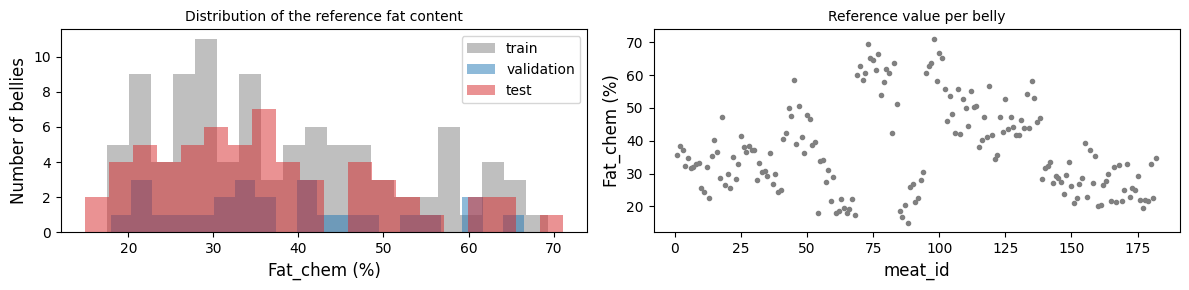

In [10]:
## Give every split a readable role name and look at the size and target range of each role
def role_of(split):
    if split in TRAIN_SPLITS:
        return 'train'
    if split in VAL_SPLITS:
        return 'validation'
    return 'test'

meta['role'] = meta['split'].apply(role_of)
display(meta.groupby('role')['Fat_chem'].describe().round(2))

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
for role, color in [('train', 'gray'), ('validation', 'tab:blue'), ('test', 'tab:red')]:
    plt.hist(meta.loc[meta.role == role, 'Fat_chem'], bins=20, alpha=0.5, label=role, color=color)
plt.xlabel('Fat_chem (%)')
plt.ylabel('Number of bellies')
plt.legend()
plt.title('Distribution of the reference fat content')
plt.subplot(1, 2, 2)
plt.plot(meta['meat_id'], meta['Fat_chem'], 'o', markersize=3, color='gray')
plt.xlabel('meat_id')
plt.ylabel('Fat_chem (%)')
plt.title('Reference value per belly')
plt.tight_layout()
plt.show()

Note how wide the range is: from lean bellies with about 15% fat to very fat ones above 70%. The pigs came from five different fat classes (common commercial pigs, Duroc pigs and Iberian crossbreds), so the dataset deliberately covers a lot of variation.

### 3.2) The mean spectra

The camera records 300 wavelength channels between about 387 nm and 1016 nm. Only the last 124 channels, from 747.92 nm upwards, are used. This has two benefits: fewer numbers to process, and the models focus on chemical information (the near-infrared overtones of C-H and O-H bonds) instead of the colour of the meat.

For every belly, a mean absorbance spectrum was computed beforehand: each pixel reflectance $R$ was converted to absorbance $A = -\log_{10}(R)$ and all pixels inside the meat masks of all slices of the belly were averaged. The function `load_spectrum` below is the single place where a spectrum is read from disk and cut to the last 124 channels. 

In [11]:
## Number of trailing wavelength channels kept from each 300-channel mean spectrum
NUM_SPECTRAL_CHANNELS = 124
SPECTRUM_LENGTH = NUM_SPECTRAL_CHANNELS

## Approximate wavelength axis of the 124 channels used (from 747.92 nm to 1015.78 nm, as stated in the paper)
WAVELENGTHS = np.linspace(747.92, 1015.78, NUM_SPECTRAL_CHANNELS)


def load_spectrum(path, dtype=np.float32):
    '''Load one mean spectrum and keep only the last NUM_SPECTRAL_CHANNELS channels.'''
    spectrum = np.load(path).astype(dtype)
    return spectrum[-NUM_SPECTRAL_CHANNELS:]


def load_spectra_arrays(splits):
    '''Return (X, Y, meat_ids) for all bellies whose split is in splits.
    X: (n, 124) mean spectra, Y: (n, 1) reference fat values.'''
    df = meta[meta['split'].isin(splits)]
    X, Y, ids = [], [], []
    for _, row in df.iterrows():
        f = SPECTRA_PATH / f"{int(row['meat_id'])}.npy"
        if not f.exists():
            continue
        X.append(load_spectrum(f, dtype=np.float64))
        Y.append([float(row[c]) for c in REFERENCE_VALUES])
        ids.append(int(row['meat_id']))
    return np.stack(X), np.asarray(Y, dtype=np.float64), ids


X_train, Y_train, ids_train = load_spectra_arrays(TRAIN_SPLITS)
X_val, Y_val, ids_val = load_spectra_arrays(VAL_SPLITS)
X_test, Y_test, ids_test = load_spectra_arrays(TEST_SPLITS)
print('Train     :', X_train.shape, Y_train.shape)
print('Validation:', X_val.shape, Y_val.shape)
print('Test      :', X_test.shape, Y_test.shape)

Train     : (97, 124) (97, 1)
Validation: (25, 124) (25, 1)
Test      : (60, 124) (60, 1)


Let us look at one complete 300-channel spectrum first, to see which part we keep, and then at all training spectra coloured by their fat content. This is a useful visualisation technique to check whether there is a visible relationship between the spectra and the target before any modelling.

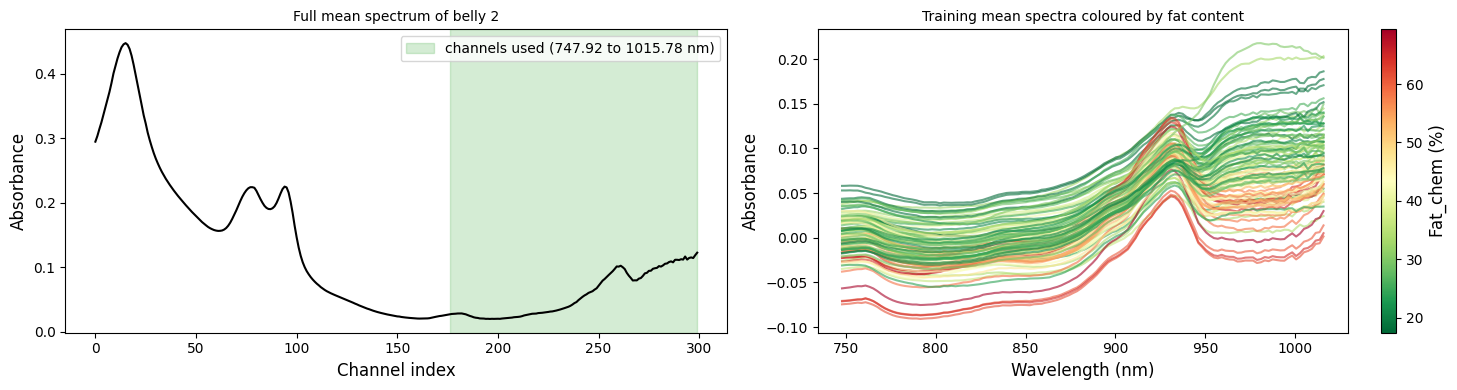

In [12]:
example_full = np.load(SPECTRA_PATH / f'{ids_train[0]}.npy')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
ax = axes[0]
ax.plot(np.arange(len(example_full)), example_full, 'k')
ax.axvspan(len(example_full) - NUM_SPECTRAL_CHANNELS, len(example_full) - 1, color='tab:green', alpha=0.2,
           label='channels used (747.92 to 1015.78 nm)')
ax.set_xlabel('Channel index')
ax.set_ylabel('Absorbance')
ax.set_title(f'Full mean spectrum of belly {ids_train[0]}')
ax.legend()

## Colour the spectra according to the target variable ('RdYlGn_r': green for lean, red for fat)
ax = axes[1]
cmap = plt.get_cmap('RdYlGn_r')
norm = mcolors.Normalize(vmin=Y_train.min(), vmax=Y_train.max())
for x, y in zip(X_train, Y_train[:, 0]):
    ax.plot(WAVELENGTHS, x, color=cmap(norm(y)), alpha=0.6)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Fat_chem (%)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.set_title('Training mean spectra coloured by fat content')
plt.tight_layout()
plt.show()

A large part of the variation between spectra is a vertical offset and a change in slope. These are mostly caused by light scattering and by differences in sample geometry, not by chemistry. The chemical signal sits in the smaller features, for example around 930 nm, where the third overtone of the C-H bond in fat absorbs. A good model must separate these two kinds of variation.

### 3.3) A first look with PCA

A principal component analysis compresses each spectrum into a few scores. Colouring the scores by fat content shows whether fat is one of the dominant directions of variation in the data.

Explained variance ratios: [0.9126 0.0567 0.0245]


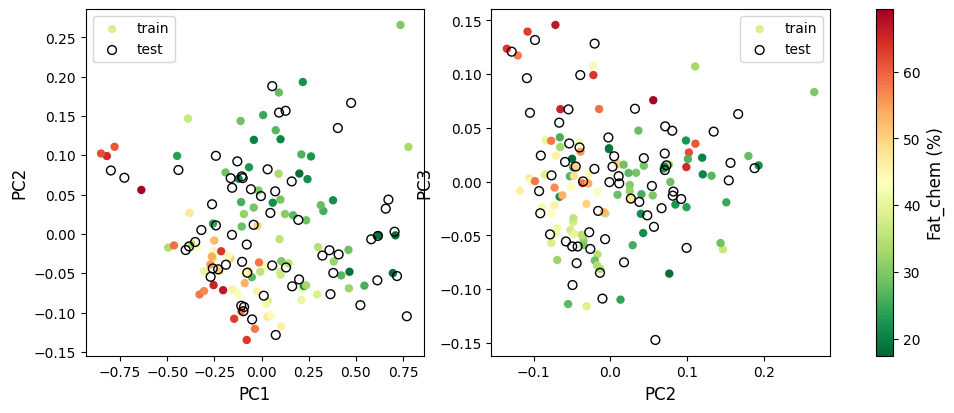

In [13]:
pca = PCA(n_components=3).fit(X_train)
scores_train = pca.transform(X_train)
scores_test = pca.transform(X_test)
print('Explained variance ratios:', np.round(pca.explained_variance_ratio_, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    sc = ax.scatter(scores_train[:, i], scores_train[:, j], c=Y_train[:, 0], cmap='RdYlGn_r', s=25, label='train')
    ax.scatter(scores_test[:, i], scores_test[:, j], facecolors='none', edgecolors='k', s=40, label='test')
    ax.set_xlabel(f'PC{i + 1}')
    ax.set_ylabel(f'PC{j + 1}')
    ax.legend()
fig.colorbar(sc, ax=axes, label='Fat_chem (%)')
plt.show()

### 3.4) Standardisation statistics

Neural networks train best when their inputs and outputs are of order one. We standardise with one global scalar mean and one global scalar standard deviation, computed over all training spectra and all wavelengths together:
$$x_{std} = \frac{x - \mu_X}{\sigma_X}, \qquad y_{std} = \frac{y - \mu_y}{\sigma_y}$$

Why a single scalar and not one value per wavelength (column-wise standardisation)? Column-wise scaling would change the shape of every spectrum, it blows up noisy wavelengths with little variance and destroys the relationship between neighbouring channels. A global scalar keeps the spectral shape intact, which matters for the convolutional models that look at local spectral patterns.

Two rules are essential here:

1. The statistics come from the training split only. Using validation or test data here would leak information about data the model is supposed to never have seen.
2. The statistics are stored inside the model (we will see how in section 5), so that a saved model can never be used with the wrong scaling.

Computing these numbers takes a few lines. The course folder also contains the values as small files, which we use as a cross-check.

In [14]:
## Input statistics: one scalar over all training spectra and all wavelengths
SPECTRA_MEAN = float(X_train.mean())
SPECTRA_STD = float(X_train.std())

## Target statistics: one scalar over all training bellies
y_train_csv = meta.loc[meta['split'].isin(TRAIN_SPLITS), REFERENCE_VALUES].to_numpy(dtype=np.float64)
TARGET_MEAN = float(y_train_csv.mean())
TARGET_STD = float(y_train_csv.std())

print(f'Spectra: mean = {SPECTRA_MEAN:.6f}, std = {SPECTRA_STD:.6f}')
print(f'Target : mean = {TARGET_MEAN:.4f}, std = {TARGET_STD:.4f}')

Spectra: mean = 0.031223, std = 0.049720
Target : mean = 37.9531, std = 13.7968


## 4) PLS modelling

Partial Least Squares regression is the workhorse of chemometrics and our baseline. PLS is linear: the prediction is a weighted sum of the 124 absorbances plus an offset,
$$\hat{y} = \bar{y} + (\mathbf{x} - \bar{\mathbf{x}})^\top \mathbf{b}.$$

With 97 training bellies and 124 strongly correlated wavelengths, ordinary least squares would fit noise perfectly. PLS avoids this by building the regression vector $\mathbf{b}$ from a small number $A$ of latent variables (components). Each component is a direction in spectral space chosen to maximise the covariance between the spectra and the fat content. The number of components is the single hyperparameter: too few and the model misses chemistry (underfitting), too many and it starts to model noise (overfitting).

The study used the Improved Kernel PLS Algorithm 1 from the `ikpls` package. It fits the models for all component counts 1 to 20 in one go, which makes selecting $A$ on the validation set very cheap. The spectra and the target are mean-centred but not scaled.

Shape of all validation predictions: (20, 25, 1)
Best number of components: 6 (validation RMSE = 4.234)


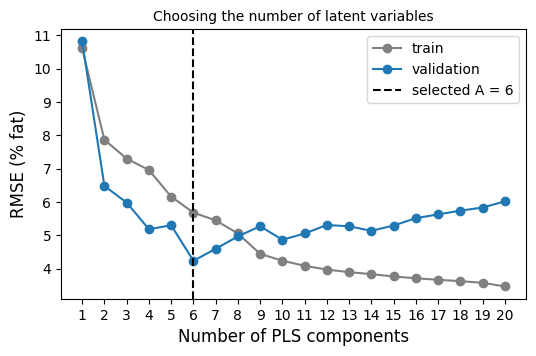

In [15]:
MAX_COMPONENTS = 20

## Fit PLS models with 1 ... 20 components on the training split at once
pls = PLS(algorithm=1, center_X=True, center_Y=True, scale_X=False, scale_Y=False)
pls.fit(X_train, Y_train, A=MAX_COMPONENTS)

## predict() without n_components returns the predictions of ALL component counts: shape (A, n, 1)
Y_train_pred_all = pls.predict(X_train)
Y_val_pred_all = pls.predict(X_val)
print('Shape of all validation predictions:', Y_val_pred_all.shape)

train_rmse_per_a = np.sqrt(np.mean((Y_train[None] - Y_train_pred_all) ** 2, axis=(1, 2)))
val_rmse_per_a = np.sqrt(np.mean((Y_val[None] - Y_val_pred_all) ** 2, axis=(1, 2)))
best_a = int(np.argmin(val_rmse_per_a)) + 1   # component counts are 1-indexed
print(f'Best number of components: {best_a} (validation RMSE = {val_rmse_per_a[best_a - 1]:.3f})')

comps = np.arange(1, MAX_COMPONENTS + 1)
plt.figure(figsize=(6, 3.5))
plt.plot(comps, train_rmse_per_a, 'o-', color='gray', label='train')
plt.plot(comps, val_rmse_per_a, 'o-', color='tab:blue', label='validation')
plt.axvline(best_a, color='k', ls='--', label=f'selected A = {best_a}')
plt.xlabel('Number of PLS components')
plt.ylabel('RMSE (% fat)')
plt.xticks(comps)
plt.legend()
plt.title('Choosing the number of latent variables')
plt.show()

The training error keeps decreasing with every extra component, while the validation error reaches a minimum and then flattens or rises again. That minimum is our choice of $A$. Now we predict the test set with the selected model, and look at the regression vector $\mathbf{b}$, which tells us which wavelengths the model relies on.

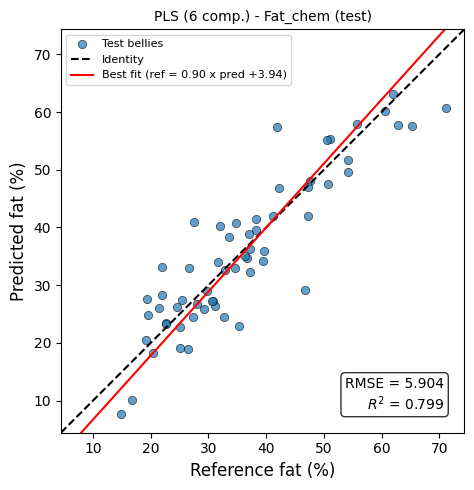

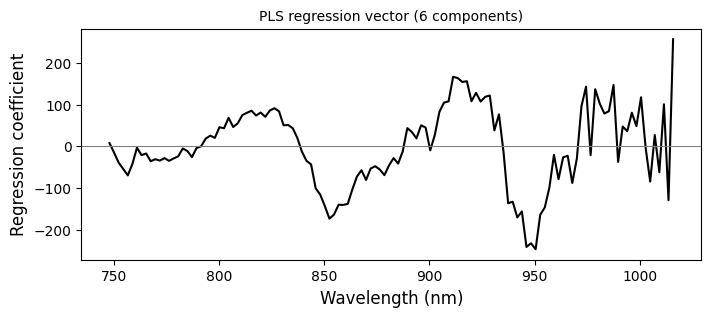

In [16]:
pls_test_pred = pls.predict(X_test, n_components=best_a).reshape(-1)
pls_rmse, pls_r2 = prediction_scatter_plot(pls_test_pred, Y_test.reshape(-1), f'PLS ({best_a} comp.) - Fat_chem (test)')

## Store the test predictions for the final comparison
results['PLS'] = pd.DataFrame({'meat_id': ids_test, 'true': Y_test.reshape(-1), 'pred': pls_test_pred})

## The regression coefficients of the selected model: pls.B has shape (A, n_wavelengths, n_targets)
plt.figure(figsize=(8, 3))
plt.plot(WAVELENGTHS, pls.B[best_a - 1, :, 0], 'k')
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Regression coefficient')
plt.title(f'PLS regression vector ({best_a} components)')
plt.show()

## 5) A neural network toolbox

All neural models in this notebook share the same plumbing: a way to scale inputs and outputs, a way to feed data, and a training loop. We build them here once, step by step, and reuse them for the MLP, the 1D ResNet, the 2D ResNet and the ViT.

### 5.1) Standardisation baked into the model

The two classes below are tiny, but they encode an important design decision. Instead of scaling the data outside of the model (and hoping that nobody forgets it at prediction time), the scaling constants are stored inside the model as buffers. A buffer is a tensor that belongs to the model and is saved in its checkpoint file, but is not trained by the optimizer.

- `InputStandardizer` computes $(x - \mu) / \sigma$ on the way in.
- `OutputDestandardizer` computes $\hat{y}_{std} \cdot \sigma_y + \mu_y$ on the way out.

The network in between therefore always works with numbers of order one, while the model as a whole takes raw absorbance and returns fat in percent. The loss can be computed directly in percent against the raw reference values.

In [17]:
class InputStandardizer(nn.Module):
    '''(x - mean) / std with scalar mean and std stored as buffers (saved in the checkpoint).'''

    def __init__(self, mean: float = 0.0, std: float = 1.0):
        super().__init__()
        self.register_buffer('mean', torch.tensor(float(mean)))
        self.register_buffer('std', torch.tensor(float(std)))

    def forward(self, x):
        return (x - self.mean) / self.std


class OutputDestandardizer(nn.Module):
    '''x * std + mean: the inverse of InputStandardizer, placed at the output of a regressor.'''

    def __init__(self, mean: float = 0.0, std: float = 1.0):
        super().__init__()
        self.register_buffer('mean', torch.tensor(float(mean)))
        self.register_buffer('std', torch.tensor(float(std)))

    def forward(self, x):
        return x * self.std + self.mean


class SpectrumRegressor(nn.Module):
    '''Standardise the spectrum, apply the backbone (MLP or 1D ResNet), de-standardise the output.
    add_channel_dim=True turns (B, L) into (B, 1, L), the layout a 1D convolution expects.'''

    def __init__(self, backbone, add_channel_dim=False, mean=0.0, std=1.0, out_mean=0.0, out_std=1.0):
        super().__init__()
        self.standardizer = InputStandardizer(mean, std)
        self.backbone = backbone
        self.add_channel_dim = add_channel_dim
        self.destandardizer = OutputDestandardizer(out_mean, out_std)

    def forward(self, x):
        x = self.standardizer(x)
        if self.add_channel_dim:
            x = x.unsqueeze(1)
        x = self.backbone(x)
        return self.destandardizer(x)

### 5.2) Feeding the data: Dataset and DataLoader

PyTorch separates "what is one sample" from "how samples are grouped into batches":

- A `Dataset` answers two questions: how many samples are there (`__len__`) and what is sample number `idx` (`__getitem__`). Ours returns a tuple `(spectrum, reference, meat_id)`.
- A `DataLoader` draws samples from the dataset, optionally shuffles them, and stacks them into batches.

With only 97 training bellies, we use a batch size of 512. That is larger than the training set, so every batch contains all bellies. This is called full-batch gradient descent: each epoch is exactly one optimizer step, computed on the whole training set. That is why the spectral models need many epochs (up to 2000) and a relatively high learning rate.

In [18]:
class MeanSpectrumDataset(Dataset):
    '''One item per belly: (spectrum (124,), reference (1,), meat_id as string).'''

    def __init__(self, splits):
        df = meta[meta['split'].isin(splits)].set_index('meat_id')
        self.df = df
        self.items = []
        for meat_id in sorted(int(m) for m in df.index.values):
            f = SPECTRA_PATH / f'{meat_id}.npy'
            if not f.exists():
                raise ValueError(f'Mean spectrum for {meat_id} not found: {f}')
            self.items.append((meat_id, f))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        meat_id, f = self.items[idx]
        spectrum = torch.from_numpy(load_spectrum(f))                       # (124,)
        refs = torch.tensor(self.df.loc[meat_id, REFERENCE_VALUES].values.astype(np.float32))  # (1,)
        return spectrum, refs, str(meat_id)


def spectrum_loader(splits, shuffle, batch_size=512):
    return DataLoader(MeanSpectrumDataset(splits), batch_size=batch_size, shuffle=shuffle)


## Look at one batch
xb, yb, idb = next(iter(spectrum_loader(TRAIN_SPLITS, shuffle=True)))
print('spectra batch:', tuple(xb.shape), xb.dtype)
print('targets batch:', tuple(yb.shape), yb.dtype)
print('first ids    :', idb[:5])

spectra batch: (97, 124) torch.float32
targets batch: (97, 1) torch.float32
first ids    : ('160', '79', '110', '45', '72')


### 5.3) The training loop, unpacked

Below is the complete training procedure, written as one readable function. It is long, so here is the recipe first:

1. Optimizer: AdamW. Adam adapts the step size of every parameter using running averages of its gradients. The W stands for decoupled weight decay: at every step all weights are shrunk a little towards zero, which acts as a regulariser. Weight decay is applied only to weight matrices and convolution kernels, not to biases.
2. Loss: the mean squared error between predicted and reference fat, in percent.
3. Model selection: after every epoch the model is evaluated on the whole training set and the whole validation set. Whenever the validation MSE reaches a new minimum, the weights (and the optimizer state) are saved as the current best weights.
4. Burn-in: during the first epochs the learning rate is never touched and training is never stopped. Early epochs are noisy, and we do not want to react to that noise.
5. Learning-rate reduction on plateau: after burn-in, if the validation MSE has not improved for a number of epochs (the patience), the learning rate is divided by 10 (but never below $10^{-7}$). Right before the learning rate is reduced, the model is reset to its best weights, so that training continues from a known good state with smaller steps.
6. Early stopping: if the validation MSE has not improved for a (longer) patience, training stops.
7. Finalisation: the best weights are restored, and a bias and scale correction (Igel and Oehmichen, 2023) is fitted on the training and validation predictions and folded into the model.

About step 7: a PLS model fitted by least squares is guaranteed to have a best-fit line with slope one and intercept zero on its calibration data. A neural network trained with a stochastic optimizer and early stopping has no such guarantee. The correction solves $y = a + b\,\hat{y}$ by ordinary least squares on training plus validation predictions (never on the test set), and writes it into the `OutputDestandardizer`:
$$b(\hat{y}_{std}\,\sigma + \mu) + a = \hat{y}_{std}\,(b\,\sigma) + (b\,\mu + a).$$
So we only need to update the two stored buffers, and no extra layer is required.

In [19]:
def make_adamw(model, lr, weight_decay):
    '''AdamW with weight decay only on multi-dimensional weights (not on biases or 1D parameters).'''
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim == 1 or name.endswith('bias'):
            no_decay.append(param)
        else:
            decay.append(param)
    return torch.optim.AdamW([{'params': decay, 'weight_decay': weight_decay},
                              {'params': no_decay, 'weight_decay': 0.0}], lr=lr)


def mse_on_loader(model, loader, device):
    '''Mean squared error over a whole loader (sum of squared errors / number of samples).'''
    model.eval()
    sse, n = 0.0, 0
    with torch.no_grad():
        for inputs, targets, _ in loader:
            preds = model(to_device(inputs, device)).reshape(-1, 1)
            targets = targets.to(device).reshape(-1, 1)
            sse += float(((targets - preds) ** 2).sum())
            n += targets.shape[0]
    return sse / n


def predict_loader(model, loader, device):
    '''Return (meat_ids, predictions, references) as NumPy arrays.'''
    model.eval().to(device)
    ids, preds, trues = [], [], []
    with torch.no_grad():
        for inputs, targets, file_ids in loader:
            out = model(to_device(inputs, device))
            preds.append(out.detach().cpu().reshape(-1))
            trues.append(targets.reshape(-1))
            ids.extend(int(i) for i in file_ids)
    return np.array(ids), torch.cat(preds).numpy(), torch.cat(trues).numpy()


def correct_bias_and_scale(model, train_eval_loader, val_loader, device):
    '''Fit y = bias + scale * prediction on train + validation, fold it into model.destandardizer.'''
    _, p_tr, t_tr = predict_loader(model, train_eval_loader, device)
    _, p_va, t_va = predict_loader(model, val_loader, device)
    pred = np.concatenate([p_tr, p_va]).astype(np.float64)
    true = np.concatenate([t_tr, t_va]).astype(np.float64)
    X = np.stack([np.ones_like(pred), pred], axis=1)          # columns [1, prediction]
    bias, scale = np.linalg.lstsq(X, true, rcond=None)[0]
    print(f'Correcting bias and scale: scale = {scale:.6f}, bias = {bias:.6f}')
    layer = model.destandardizer
    with torch.no_grad():
        layer.std.mul_(float(scale))
        layer.mean.mul_(float(scale)).add_(float(bias))

The next cell contains the training function itself. 

In [20]:
def train_regressor(model, train_loader, val_loader, train_eval_loader, save_dir,
                    init_lr=1e-3, weight_decay=1e-4, max_epochs=250, burn_in_epochs=30,
                    reduce_lr_patience=10, early_stop_patience=30, lr_multiplier=0.1, min_lr=1e-7,
                    correct_regressor=True, device=DEVICE, print_every=10):
    '''Train a scalar regressor with burn-in, plateau schedule, weight restoring and early stopping.
    Writes save_dir/best_weights.pt and returns a history dictionary.'''
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    best_path = save_dir / 'best_weights.pt'
    optim_path = save_dir / 'best_weights_optim_state.pt'

    model.to(device)
    optimizer = make_adamw(model, init_lr, weight_decay)
    ## patience - 1 because ReduceLROnPlateau reduces only AFTER 'patience' bad epochs, while we want
    ## the reduction on the reduce_lr_patience-th epoch without improvement
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=reduce_lr_patience - 1, factor=lr_multiplier, min_lr=min_lr)

    ## The loss is a sum of squared errors divided by the average batch size of the epoch
    avg_batch_size = len(train_loader.dataset) / len(train_loader)

    def save_checkpoint():
        torch.save(model.state_dict(), best_path)
        torch.save(optimizer.state_dict(), optim_path)

    def restore_checkpoint():
        ## Restore the best weights and optimizer state, but keep the current (reduced) learning rate
        current_lr = optimizer.param_groups[0]['lr']
        model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
        optimizer.load_state_dict(torch.load(optim_path, map_location=device, weights_only=True))
        optimizer.param_groups[0]['lr'] = current_lr

    best_val = float('inf')          # best validation MSE seen so far (model checkpoint)
    best_burn_in_val = float('inf')  # best validation MSE seen during burn-in
    early_best = float('inf')        # reference value of the early-stopping counter
    early_counter = 0
    history = {'epoch': [], 'train_mse': [], 'val_mse': [], 'lr': [], 'best_epoch': None}
    save_checkpoint()                # the untrained model is the first 'best' model

    for epoch in tqdm(range(1, max_epochs + 1), desc='Epochs'):
        ## ---- 1. one pass over the training data, updating the weights ----
        model.train()
        for inputs, targets, _ in train_loader:
            inputs, targets = to_device(inputs, device), targets.to(device)
            optimizer.zero_grad()
            preds = model(inputs)
            ## reshape both to (B, 1) to avoid a silent (B,) x (B, 1) broadcast to (B, B)
            loss = ((targets.reshape(-1, 1) - preds.reshape(-1, 1)) ** 2).sum() / avg_batch_size
            loss.backward()
            optimizer.step()

        ## ---- 2. evaluate the epoch's final weights on the full training and validation sets ----
        train_mse = mse_on_loader(model, train_eval_loader, device)
        val_mse = mse_on_loader(model, val_loader, device)
        cur_lr = optimizer.param_groups[0]['lr']
        for k, v in [('epoch', epoch), ('train_mse', train_mse), ('val_mse', val_mse), ('lr', cur_lr)]:
            history[k].append(v)

        ## ---- 3. model checkpoint: keep the weights with the lowest validation MSE ----
        if epoch <= burn_in_epochs:
            best_burn_in_val = min(best_burn_in_val, val_mse)
        if val_mse < best_val:
            best_val = val_mse
            history['best_epoch'] = epoch
            save_checkpoint()

        if epoch % print_every == 0 or epoch == 1:
            print(f'epoch {epoch:4d} | train MSE {train_mse:9.3f} | val MSE {val_mse:9.3f} | lr {cur_lr:.1e}')

        ## ---- 4. end of burn-in: initialise early stopping and the scheduler ----
        if epoch == burn_in_epochs:
            print('Burn-in epochs completed.')
            early_best = min(early_best, best_burn_in_val)
            scheduler.step(best_burn_in_val)

        ## ---- 5. after burn-in: early stopping and learning-rate reduction ----
        if epoch > burn_in_epochs:
            if val_mse < early_best:
                early_best, early_counter = val_mse, 0
            else:
                early_counter += 1
            if early_counter >= early_stop_patience:
                print(f'Early stopping at epoch {epoch}')
                break
            scheduler.step(val_mse)
            new_lr = optimizer.param_groups[0]['lr']
            if new_lr < cur_lr:
                print(f'epoch {epoch}: learning rate reduced from {cur_lr:.1e} to {new_lr:.1e}. Restoring best weights.')
                restore_checkpoint()

    ## ---- 6. finalise: best weights, bias and scale correction, save ----
    print(f"Finalizing training. Best epoch: {history['best_epoch']} (validation MSE {best_val:.3f})")
    model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    if correct_regressor:
        correct_bias_and_scale(model, train_eval_loader, val_loader, device)
    torch.save(model.state_dict(), best_path)
    pd.DataFrame({k: v for k, v in history.items() if k != 'best_epoch'}).to_csv(save_dir / 'logs.csv', index=False)
    print('Final train MSE:', round(mse_on_loader(model, train_eval_loader, device), 3),
          '| final validation MSE:', round(mse_on_loader(model, val_loader, device), 3))
    print('Saved weights to', best_path)
    return history


def plot_history(history, title):
    fig, ax1 = plt.subplots(figsize=(7, 3.5))
    ax1.plot(history['epoch'], history['train_mse'], label='train MSE', color='gray')
    ax1.plot(history['epoch'], history['val_mse'], label='validation MSE', color='tab:blue')
    if history['best_epoch'] is not None:
        ax1.axvline(history['best_epoch'], color='k', ls='--', label='best epoch')
    ax1.set_yscale('log')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE (% fat squared)')
    ax2 = ax1.twinx()
    ax2.plot(history['epoch'], history['lr'], color='tab:orange', alpha=0.6, label='learning rate')
    ax2.set_yscale('log')
    ax2.set_ylabel('Learning rate')
    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc='upper right', fontsize=8)
    ax1.set_title(title)
    plt.tight_layout()
    plt.show()

### 5.4) Loading trained weights

The last helper implements the GPU CHECKPOINT logic. It builds a fresh model with the `build_...` function of that model, decides which weight file to use (your own run or the pre-trained file, controlled by `WEIGHTS_SOURCE` in section 0) and loads it. Loading on a CPU works because of `map_location`, which moves every stored tensor to the device we ask for.

In [21]:
def load_trained_model(build_fn, name, source=None, device=DEVICE):
    source = source or WEIGHTS_SOURCE
    own = RUN_DIR / name / 'best_weights.pt'
    pretrained = PRETRAINED_DIR / name / 'best_weights.pt'
    if source == 'own' or (source == 'auto' and own.exists()):
        path = own
    else:
        path = pretrained
    if not path.exists():
        raise FileNotFoundError(f'No weights found at {path}. Train the model above or check PRETRAINED_DIR.')
    model = build_fn()
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.to(device).eval()
    print(f'Loaded {name} weights from {path}')
    return model

## 6) The Multilayer Perceptron (MLP)

### 6.1) Theory in a nutshell

The MLP is the simplest neural network. It stacks fully connected (linear) layers with a non-linear activation in between:
$$\mathbf{h}_1 = \mathrm{ReLU}(W_1\mathbf{x} + \mathbf{b}_1), \quad \mathbf{h}_2 = \mathrm{ReLU}(W_2\mathbf{h}_1 + \mathbf{b}_2), \quad \hat{y} = \mathbf{w}_3^\top\mathbf{h}_2 + b_3$$

Compared with PLS, two things change:

- Non-linearity. The ReLU function, $\mathrm{ReLU}(z) = \max(0, z)$, lets the network bend the relationship between spectrum and fat. Without it, the three layers would collapse into one linear model, just like PLS.
- Capacity. Here the hidden layers have 256 and 128 neurons. The first layer alone has $124 \times 256 + 256 = 32{,}000$ parameters, for only 97 training samples. Overfitting is the main danger, which is why the training loop watches the validation error so closely.

What the MLP does not know: it treats the 124 inputs as an unordered list. Shuffle the wavelengths (the same way for every sample) and the MLP would learn equally well. It has no notion that neighbouring wavelengths are related. The 1D ResNet in the next section changes exactly that.

Note the `get_norm_layer` function in the class below: the code can insert batch normalisation (`'bn'`) or layer normalisation (`'ln'`) after each linear layer. The experiments use `None`, which inserts an `nn.Identity` (a layer that does nothing) so that the layer numbering stays the same in every configuration.

In [22]:
def get_norm_layer_1d(normalization, num_features):
    '''Normalisation over the feature dimension of a (B, F) tensor: 'bn', 'ln' or None (identity).'''
    if normalization == 'bn':
        return nn.BatchNorm1d(num_features, momentum=0.01)
    if normalization == 'ln':
        return nn.LayerNorm(num_features)
    if normalization is None:
        return nn.Identity()
    raise ValueError("normalization must be None, 'bn' or 'ln'")


class MLP(nn.Module):
    '''A stack of (Linear -> normalisation -> ReLU -> Dropout) blocks followed by a linear head.'''

    def __init__(self, input_dim=300, hidden_dims=(256, 128), output_dim=1, normalization=None, dropout=0.0):
        super().__init__()
        ## A bias in the linear layer is only needed when no normalisation layer follows
        bias = normalization is None
        layers = []
        in_features = input_dim
        for hidden in hidden_dims:
            layers.append(nn.Linear(in_features, hidden, bias=bias))
            layers.append(get_norm_layer_1d(normalization, hidden))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden
        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(in_features, output_dim)

    def forward(self, x):
        return self.head(self.features(x))


def build_mlp():
    backbone = MLP(input_dim=SPECTRUM_LENGTH, hidden_dims=(256, 128), output_dim=1, normalization=None, dropout=0.0)
    return SpectrumRegressor(backbone, add_channel_dim=False,
                             mean=SPECTRA_MEAN, std=SPECTRA_STD, out_mean=TARGET_MEAN, out_std=TARGET_STD)


mlp = build_mlp()
print(mlp)
display(trace_shapes(mlp, torch.randn(4, SPECTRUM_LENGTH), max_depth=3))

SpectrumRegressor(
  (standardizer): InputStandardizer()
  (backbone): MLP(
    (features): Sequential(
      (0): Linear(in_features=124, out_features=256, bias=True)
      (1): Identity()
      (2): ReLU(inplace=True)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): Identity()
      (5): ReLU(inplace=True)
    )
    (head): Linear(in_features=128, out_features=1, bias=True)
  )
  (destandardizer): OutputDestandardizer()
)
Final output shape: (4, 1) | trainable parameters: 65,025


,module,type,output shape (first call),parameters,calls
0,standardizer,InputStandardizer,"(4, 124)",0,1
1,backbone.features.0,Linear,"(4, 256)",32000,1
2,backbone.features.1,Identity,"(4, 256)",0,1
3,backbone.features.2,ReLU,"(4, 256)",0,1
4,backbone.features.3,Linear,"(4, 128)",32896,1
5,backbone.features.4,Identity,"(4, 128)",0,1
6,backbone.features.5,ReLU,"(4, 128)",0,1
7,backbone.features,Sequential,"(4, 128)",64896,1
8,backbone.head,Linear,"(4, 1)",129,1
9,backbone,MLP,"(4, 1)",65025,1


### 6.2) Train the MLP

Because training is full-batch (one optimizer step per epoch), the learning rate is high ($10^{-2}$), the epoch budget is large (2000) and the burn-in and patience values are large as well (100, 40 and 200 epochs). This model is small enough to train on a CPU in a few minutes.

Epochs:   0%|          | 3/2000 [00:00<06:24,  5.19it/s]

epoch    1 | train MSE   315.544 | val MSE   406.147 | lr 1.0e-02


Epochs:   5%|▌         | 101/2000 [00:07<02:07, 14.89it/s]

epoch  100 | train MSE    32.067 | val MSE    47.821 | lr 1.0e-02
Burn-in epochs completed.


Epochs:   7%|▋         | 141/2000 [00:10<02:08, 14.41it/s]

...

epoch  300 | train MSE    35.153 | val MSE    29.638 | lr 1.0e-06
epoch 302: learning rate reduced from 1.0e-06 to 1.0e-07. Restoring best weights.


Epochs:  20%|██        | 401/2000 [00:29<01:52, 14.25it/s]

epoch  400 | train MSE    35.107 | val MSE    29.816 | lr 1.0e-07


Epochs:  21%|██        | 421/2000 [00:30<01:55, 13.68it/s]


Early stopping at epoch 422
Finalizing training. Best epoch: 222 (validation MSE 29.039)
Correcting bias and scale: scale = 0.990363, bias = -0.355681
Final train MSE: 35.419 | final validation MSE: 29.498
Saved weights to mlp/best_weights.pt


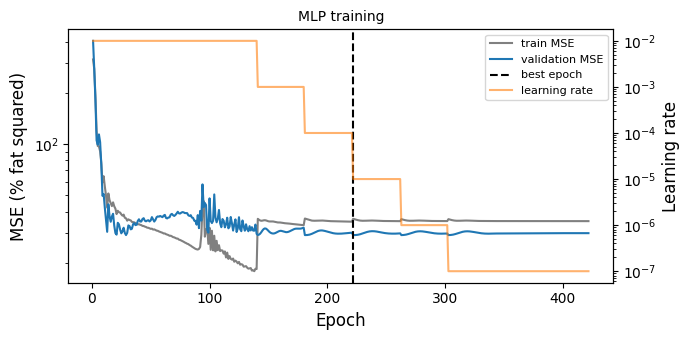

In [23]:
reproducible_comp()
mlp = build_mlp()
mlp_history = train_regressor(
    mlp,
    train_loader=spectrum_loader(TRAIN_SPLITS, shuffle=True),
    val_loader=spectrum_loader(VAL_SPLITS, shuffle=False),
    train_eval_loader=spectrum_loader(TRAIN_SPLITS, shuffle=False),
    save_dir=RUN_DIR / 'mlp',
    init_lr=1e-2, weight_decay=1e-4,
    max_epochs=2000, burn_in_epochs=100, reduce_lr_patience=40, early_stop_patience=200,
    print_every=100,
)
plot_history(mlp_history, 'MLP training')

How to read the curves: both errors drop quickly at the start. Later the training error keeps decreasing, while the validation error stalls. Each vertical drop in the orange learning-rate curve marks a plateau: the model was reset to its best weights and continued with smaller steps. The dashed line is the epoch whose weights we keep.

### GPU CHECKPOINT: MLP

From here on you only need trained weights. The next cell loads either your own run or the pre-trained weights (see `WEIGHTS_SOURCE`), and predicts the test set. 

Loaded mlp weights from mlp/best_weights.pt


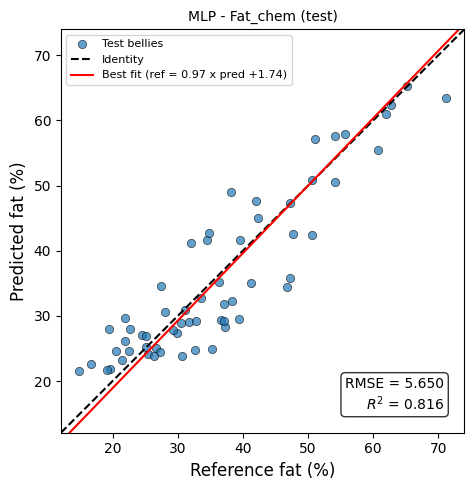

In [24]:
mlp = load_trained_model(build_mlp, 'mlp')
ids, pred, true = predict_loader(mlp, spectrum_loader(TEST_SPLITS, shuffle=False), DEVICE)
results['MLP'] = pd.DataFrame({'meat_id': ids, 'true': true, 'pred': pred})
prediction_scatter_plot(pred, true, 'MLP - Fat_chem (test)');

## 7) The 1D ResNet

### 7.1) Theory: convolutions along the wavelength axis

A 1D convolution slides a small kernel (here 3 or 7 values wide) along the spectrum and computes a weighted sum at every position:
$$h[c_{out}, i] = b_{c_{out}} + \sum_{c_{in}}\sum_{k} w[c_{out}, c_{in}, k]\; x[c_{in}, i + k].$$

Savitzky-Golay smoothing or derivative filter is exactly a 1D convolution with a fixed kernel. A convolutional network learns its own kernels instead, and many of them (64 to 512 per layer). Two properties make convolutions a natural fit for spectra:

- Locality: each output looks at a few neighbouring wavelengths, so the network starts from local spectral shapes (slopes, peaks, shoulders).
- Weight sharing: the same kernel is applied at every wavelength, so the number of parameters does not grow with the spectrum length.

Stacking many convolutions makes the network deep. Deep networks used to be hard to train, because the gradient signal fades as it travels backwards through many layers. The ResNet (He et al., 2016) solved this with residual connections: each block computes a correction $F(\mathbf{x})$ and adds it to its own input,
$$\mathbf{y} = \mathrm{ReLU}\big(F(\mathbf{x}) + \mathbf{x}\big).$$
If a block has nothing useful to add, it can simply learn $F(\mathbf{x}) \approx 0$ and pass its input on. The identity path gives the gradient a direct route back through the network.

### 7.2) A ResNet that works in 1D, 2D and 3D

We write one ResNet implementation for all three dimensionalities, adapted from the torchvision ResNet. The argument `dim` selects `Conv1d`, `Conv2d` or `Conv3d` (and the matching pooling layers). We use `dim=1` for spectra now and `dim=2` for images in section 9, so it pays off to read this code once carefully.

The ResNet-18 layout is:

- a stem: a convolution with kernel 7 and stride 2, then max pooling with stride 2 (the input length is divided by 4);
- four stages (`layer1` to `layer4`) of two `BasicBlock`s each, with 64, 128, 256 and 512 channels. Stages 2 to 4 start with stride 2, halving the length again; the shortcut then needs a 1x1 convolution (`downsample`) to match shapes;
- global average pooling over the remaining positions and a final linear layer (`fc`).

In [25]:
def conv_nd(dim):
    return {1: nn.Conv1d, 2: nn.Conv2d, 3: nn.Conv3d}[dim]


def conv3x3(dim, in_planes, out_planes, stride=1, groups=1, dilation=1, bias=False):
    '''3x3 (or length-3) convolution with padding 1, so the size only changes through the stride.'''
    return conv_nd(dim)(in_planes, out_planes, kernel_size=3, stride=stride, padding=dilation,
                        groups=groups, bias=bias, dilation=dilation)


def conv1x1(dim, in_planes, out_planes, stride=1, bias=False):
    '''1x1 convolution: mixes channels without looking at neighbours. Used to match shortcut shapes.'''
    return conv_nd(dim)(in_planes, out_planes, kernel_size=1, stride=stride, bias=bias)


class Permute(nn.Module):
    '''Permute the dimensions of a tensor (used to apply LayerNorm over the channel axis).'''

    def __init__(self, dims):
        super().__init__()
        self.dims = dims

    def forward(self, x):
        return x.permute(self.dims)


def get_norm_layer(normalization, channels, dim):
    '''Batch norm ('bn'), channel-wise layer norm ('ln') or nothing (None) for a dim-D feature map.'''
    if normalization == 'bn':
        return {1: nn.BatchNorm1d, 2: nn.BatchNorm2d, 3: nn.BatchNorm3d}[dim](channels, momentum=0.01)
    if normalization == 'ln':
        p_in = {1: (0, 2, 1), 2: (0, 2, 3, 1), 3: (0, 2, 3, 4, 1)}[dim]
        p_out = {1: (0, 2, 1), 2: (0, 3, 1, 2), 3: (0, 4, 1, 2, 3)}[dim]
        return nn.Sequential(Permute(p_in), nn.LayerNorm(channels), Permute(p_out))
    if normalization is None:
        return nn.Identity()
    raise ValueError("normalization must be None, 'bn' or 'ln'")


class BasicBlock(nn.Module):
    '''conv3x3 -> norm -> ReLU -> conv3x3 -> norm, plus the shortcut, then ReLU.'''
    expansion = 1

    def __init__(self, dim, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64,
                 dilation=1, normalization='ln'):
        super().__init__()
        bias = normalization is None
        self.conv1 = conv3x3(dim, inplanes, planes, stride, bias=bias)
        self.bn1 = get_norm_layer(normalization, planes, dim)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(dim, planes, planes, bias=bias)
        self.bn2 = get_norm_layer(normalization, planes, dim)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))      # F(x), first half
        out = self.bn2(self.conv2(out))               # F(x), second half
        if self.downsample is not None:               # match the shape of the shortcut
            identity = self.downsample(x)
        out += identity                               # the residual connection: F(x) + x
        return self.relu(out)

With these building blocks we can assemble the complete ResNet. `_make_layer` stacks the blocks of one stage and adds the 1x1 `downsample` shortcut whenever the shape changes.

In [26]:
class ResNet(nn.Module):
    def __init__(self, input_channels, dim, num_classes, block, layers, normalization='ln'):
        super().__init__()
        self.dim = dim
        self.normalization = normalization
        bias = normalization is None
        self.inplanes = 64
        self.dilation = 1
        self.groups = 1
        self.base_width = 64
        ## Stem. In 1D the spectrum always arrives as a single channel (B, 1, L)
        self.conv1 = conv_nd(dim)(input_channels if dim != 1 else 1, self.inplanes,
                                  kernel_size=7, stride=2, padding=3, bias=bias)
        self.bn1 = get_norm_layer(normalization, self.inplanes, dim)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = {1: nn.MaxPool1d, 2: nn.MaxPool2d, 3: nn.MaxPool3d}[dim](kernel_size=3, stride=2, padding=1)
        ## Four stages, each halving the spatial (or spectral) size and doubling the channels
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        ## Global average pooling: one number per channel, whatever the input size
        self.avgpool = {1: nn.AdaptiveAvgPool1d(1), 2: nn.AdaptiveAvgPool2d((1, 1)), 3: nn.AdaptiveAvgPool3d((1, 1, 1))}[dim]
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        ## Kaiming (He) initialisation, designed for ReLU networks
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.dim, self.inplanes, planes * block.expansion, stride, bias=self.normalization is None),
                get_norm_layer(self.normalization, planes * block.expansion, self.dim),
            )
        layers = [block(self.dim, self.inplanes, planes, stride, downsample, self.groups, self.base_width,
                        self.dilation, self.normalization)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.dim, self.inplanes, planes, groups=self.groups, base_width=self.base_width,
                                dilation=self.dilation, normalization=self.normalization))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = torch.flatten(self.avgpool(x), 1)
        return self.fc(x)


def resnet18(input_channels, dim, num_classes, **kwargs):
    '''ResNet-18: four stages with two BasicBlocks each.'''
    return ResNet(input_channels, dim, num_classes, BasicBlock, [2, 2, 2, 2], **kwargs)


def build_resnet1d():
    backbone = resnet18(input_channels=1, dim=1, num_classes=1, normalization=None)
    return SpectrumRegressor(backbone, add_channel_dim=True,
                             mean=SPECTRA_MEAN, std=SPECTRA_STD, out_mean=TARGET_MEAN, out_std=TARGET_STD)


resnet1d = build_resnet1d()
display(trace_shapes(resnet1d, torch.randn(4, SPECTRUM_LENGTH), max_depth=2))

Final output shape: (4, 1) | trainable parameters: 3,839,617


,module,type,output shape (first call),parameters,calls
0,standardizer,InputStandardizer,"(4, 124)",0,1
1,backbone.conv1,Conv1d,"(4, 64, 62)",512,1
2,backbone.bn1,Identity,"(4, 64, 62)",0,1
3,backbone.relu,ReLU,"(4, 64, 62)",0,1
4,backbone.maxpool,MaxPool1d,"(4, 64, 31)",0,1
5,backbone.layer1,Sequential,"(4, 64, 31)",49408,1
6,backbone.layer2,Sequential,"(4, 128, 16)",180864,1
7,backbone.layer3,Sequential,"(4, 256, 8)",722176,1
8,backbone.layer4,Sequential,"(4, 512, 4)",2886144,1
9,backbone.avgpool,AdaptiveAvgPool1d,"(4, 512, 1)",0,1


Follow the output shapes in the table: the spectrum of length 124 becomes `(B, 1, 124)` thanks to `add_channel_dim=True`, then `(B, 64, 62)` after the stem convolution, `(B, 64, 31)` after max pooling, and finally `(B, 512, 4)` after `layer4`. Average pooling then removes the wavelength axis entirely. The network has about 3.8 million parameters, roughly 60 times more than the MLP, yet it often generalises better. 

### 7.3) Train the 1D ResNet

Same recipe as the MLP (full batch, 2000 epochs at most), with a stronger weight decay of $10^{-2}$. 

Do not be alarmed if the very first epoch reports an enormous error. This ResNet has no normalisation layers, so with random initial weights its output can be far off scale. The high learning rate pulls it back within a few epochs. 

Epochs:   0%|          | 2/2000 [00:01<16:07,  2.07it/s]

epoch    1 | train MSE 50815041536.000 | val MSE 55164089139.200 | lr 1.0e-02


Epochs:   5%|▌         | 101/2000 [00:09<02:14, 14.12it/s]

epoch  100 | train MSE   181.909 | val MSE   175.172 | lr 1.0e-02
Burn-in epochs completed.


Epochs:   8%|▊         | 167/2000 [00:14<02:37, 11.66it/s]

...

epoch  300 | train MSE    32.553 | val MSE    34.267 | lr 1.0e-06


Epochs:  16%|█▋        | 330/2000 [00:29<02:46, 10.01it/s]

epoch 330: learning rate reduced from 1.0e-06 to 1.0e-07. Restoring best weights.


Epochs:  18%|█▊        | 369/2000 [00:32<02:25, 11.21it/s]


Early stopping at epoch 370
Finalizing training. Best epoch: 170 (validation MSE 33.924)
Correcting bias and scale: scale = 0.989138, bias = 0.575052
Final train MSE: 33.241 | final validation MSE: 33.89
Saved weights to resnet1d/best_weights.pt


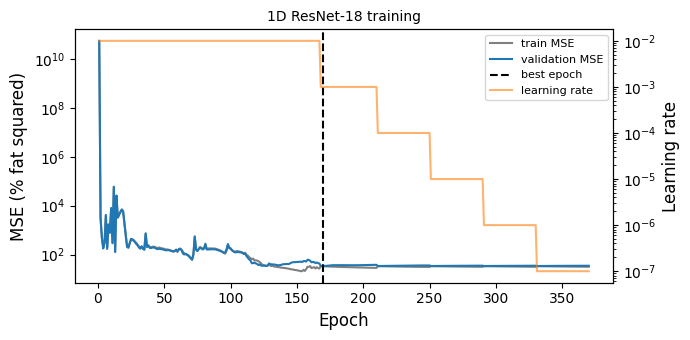

In [27]:
reproducible_comp()
resnet1d = build_resnet1d()
resnet1d_history = train_regressor(
    resnet1d,
    train_loader=spectrum_loader(TRAIN_SPLITS, shuffle=True),
    val_loader=spectrum_loader(VAL_SPLITS, shuffle=False),
    train_eval_loader=spectrum_loader(TRAIN_SPLITS, shuffle=False),
    save_dir=RUN_DIR / 'resnet1d',
    init_lr=1e-2, weight_decay=1e-2,
    max_epochs=2000, burn_in_epochs=100, reduce_lr_patience=40, early_stop_patience=200,
    print_every=100,
)
plot_history(resnet1d_history, '1D ResNet-18 training')

### GPU CHECKPOINT: 1D ResNet

Load the trained 1D ResNet (your own run or the pre-trained weights) and predict the test set.

Loaded resnet1d weights from resnet1d/best_weights.pt


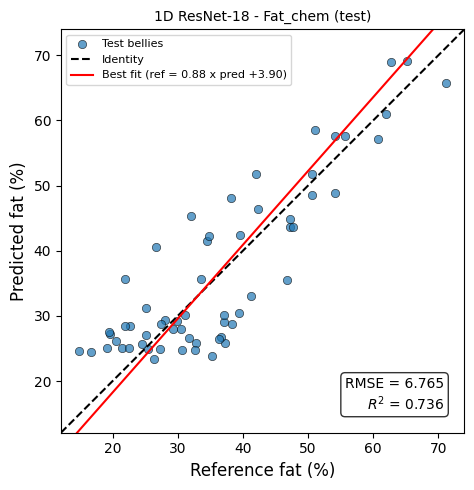

In [28]:
resnet1d = load_trained_model(build_resnet1d, 'resnet1d')
ids, pred, true = predict_loader(resnet1d, spectrum_loader(TEST_SPLITS, shuffle=False), DEVICE)
results['1D ResNet'] = pd.DataFrame({'meat_id': ids, 'true': true, 'pred': pred})
prediction_scatter_plot(pred, true, '1D ResNet-18 - Fat_chem (test)');

## 8) From mean spectra to images

So far every belly was one curve. Averaging is convenient, but it throws away everything the camera saw about where the fat is: the layers of subcutaneous fat, the muscle in between, the gradient from the back of the animal to the belly side. The next two models receive the images themselves.

This raises three practical problems that the code has to solve:

1. Size. One slice is a cube of 62 bands x about 2000 x 900 pixels. A belly with five slices is about 1.4 GB of raw data.
2. Supervision. We still only have one reference value per belly, not per slice and certainly not per pixel. The model must predict per slice, and the slice predictions must be combined into one belly prediction.
3. Background. Most of the image is conveyor belt, not meat. A mask tells the model which pixels belong to the sample.

### 8.1) What is in the image files

The images were prepared in advance:

- only the 124 channels above 747.92 nm were kept, and neighbouring channels were averaged in pairs (binning), giving 62 bands;
- the reflectance values were stored as 16-bit unsigned integers (`uint16`) to halve the file size. To convert back, every slice has two numbers, a bias and a scale: $R = q / \mathrm{scale} + \mathrm{bias}$. This is called quantisation and dequantisation. With 65536 levels the rounding error is far below the camera noise;
- every slice has a binary mask (1 = fat tissue of the belly, 0 = background), computed beforehand with a PLS discriminant analysis.

Let us open one slice and look at it.

In [29]:
INPUT_CHANNELS = 62
WAVELENGTHS_62 = WAVELENGTHS.reshape(62, 2).mean(axis=1)   # centre wavelength of each binned band


def dequantize_16_bit(arr, bias, scale):
    '''uint16 -> float reflectance: (q / scale) + bias.'''
    return (arr / scale) + bias


## The example bellies are the ones whose image files are in the course folder
EXAMPLE_BELLIES = sorted({int(f.stem.split('-')[0]) for f in (IMAGE_BASE / 'images').glob('*.npy')})
display(meta.loc[meta.meat_id.isin(EXAMPLE_BELLIES), ['meat_id', 'Fat_chem', 'role']].set_index('meat_id'))

example_id = EXAMPLE_BELLIES[0]
example_stem = sorted((IMAGE_BASE / 'images').glob(f'{example_id}-*.npy'))[0].stem
q = np.load(IMAGE_BASE / 'images' / f'{example_stem}.npy')
mask = np.load(IMAGE_BASE / 'masks' / f'{example_stem}.npy')
bias = np.load(IMAGE_BASE / 'quant_biases' / f'{example_stem}.npy')
scale = np.load(IMAGE_BASE / 'quant_scales' / f'{example_stem}.npy')
refl = dequantize_16_bit(q, bias, scale)

print(f'slice {example_stem}: stored as {q.dtype} {q.shape}, mask {mask.dtype} {mask.shape}')
print(f'bias = {float(bias):.5f}, scale = {float(scale):.1f}, reflectance range = [{refl.min():.4f}, {refl.max():.4f}]')

,Fat_chem,role
meat_id,,
10,25.48,test
70,62.78,test


slice 10-1: stored as uint16 (62, 2000, 900), mask uint8 (1, 2000, 900)
bias = 0.00000, scale = 32552.7, reflectance range = [0.0000, 2.0132]


Next we look at the slice: a false-colour picture made from three near-infrared bands, the mask, the absorbance at one wavelength, and the spectra of individual pixels.

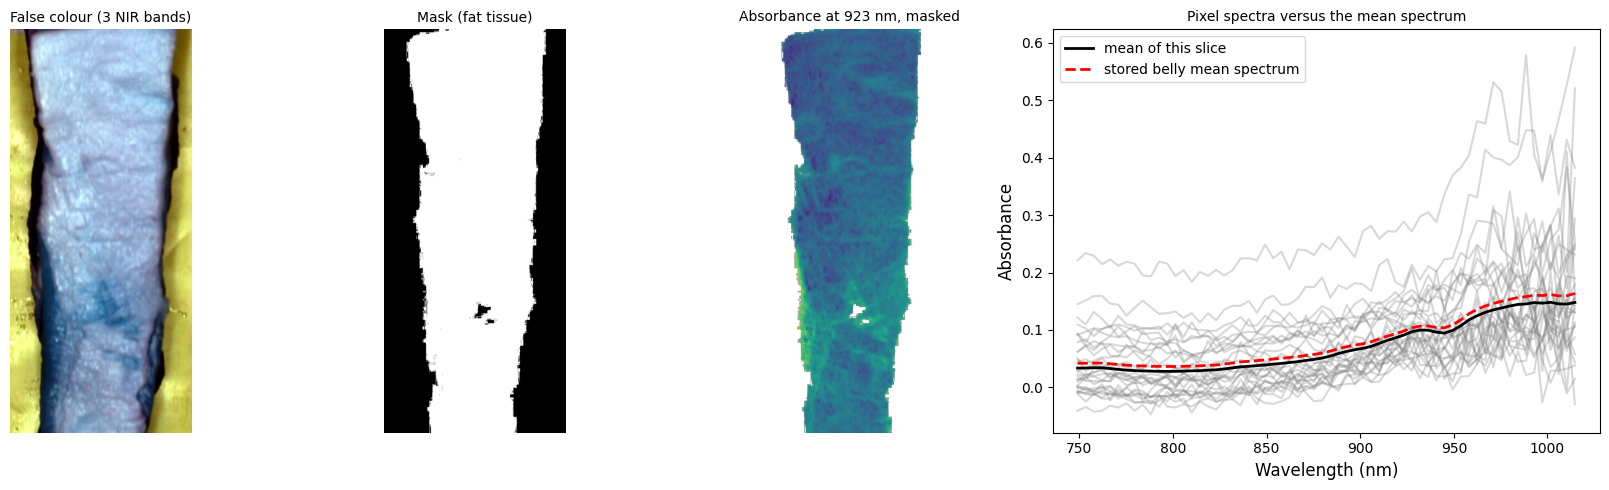

In [30]:
def false_colour(cube, bands=(55, 30, 5)):
    '''Map three bands of a (C, H, W) cube to an RGB image with a robust contrast stretch.'''
    rgb = np.stack([cube[b] for b in bands], axis=-1).astype(np.float64)
    lo, hi = np.percentile(rgb, 2, axis=(0, 1)), np.percentile(rgb, 98, axis=(0, 1))
    return np.clip((rgb - lo) / (hi - lo + 1e-12), 0, 1)


absorb = -np.log10(np.clip(refl, 1e-6, None))
m = mask[0].astype(bool)

fig, axes = plt.subplots(1, 4, figsize=(17, 5), gridspec_kw={'width_ratios': [1, 1, 1, 1.6]})
axes[0].imshow(false_colour(refl))
axes[0].set_title('False colour (3 NIR bands)')
axes[1].imshow(m, cmap='gray')
axes[1].set_title('Mask (fat tissue)')
axes[2].imshow(np.where(m, absorb[40], np.nan), cmap='viridis')
axes[2].set_title(f'Absorbance at {WAVELENGTHS_62[40]:.0f} nm, masked')
for a in axes[:3]:
    a.axis('off')

## Spectra of 30 random meat pixels, their mean, and the belly's stored mean spectrum (binned to 62 bands)
rng = np.random.default_rng(0)
pix = np.argwhere(m)
pick = pix[rng.choice(len(pix), size=min(30, len(pix)), replace=False)]
for (i, j) in pick:
    axes[3].plot(WAVELENGTHS_62, absorb[:, i, j], color='gray', alpha=0.3)
axes[3].plot(WAVELENGTHS_62, absorb[:, m].mean(axis=1), 'k', lw=2, label='mean of this slice')
stored = load_spectrum(SPECTRA_PATH / f'{example_id}.npy').reshape(62, 2).mean(axis=1)
axes[3].plot(WAVELENGTHS_62, stored, 'r--', lw=2, label='stored belly mean spectrum')
axes[3].set_xlabel('Wavelength (nm)')
axes[3].set_ylabel('Absorbance')
axes[3].set_title('Pixel spectra versus the mean spectrum')
axes[3].legend()
plt.tight_layout()
plt.show()

The grey curves show how different individual pixels are. The black curve (mean of this slice) should be close to the red dashed curve, the mean spectrum of the whole belly that the spectral models used. This is the bridge between the two worlds: the spectral models only ever saw the red curve.

### 8.2) A belly-level dataset

The image `Dataset` returns one belly per item, with all its slices. Slices of different bellies have different heights, so every slice is placed in the centre of a zero-filled canvas of one common size: the largest height and width found in the whole dataset. The function `compute_max_image_size` finds that size by reading only the file headers (memory mapping), not the data.

With only two example bellies on disk, that function would find a smaller canvas than the one used during training. For the ResNet this would not even matter much (its global average pooling accepts any size), but the ViT has one learned position embedding per image patch, so its weights only fit the original canvas. This is why `IMAGE_TARGET_SIZE` is fixed in section 0 to the value of the full dataset, (2477, 900).

During training the images can be augmented with random horizontal and vertical flips. The same flip is applied to an image and its mask, otherwise the mask would no longer match the meat. A flipped belly slice is still a valid belly slice with the same fat content, so flipping gives the model more variety for free.

An important performance trick is used here: the dataset does not dequantise. It hands over the compact `uint16` data, the `uint8` mask and the two dequantisation scalars. All conversion work happens later, on the GPU, which is much faster and moves half as many bytes between CPU and GPU.

A custom `collate` function is needed. The default would add a batch axis in front of the slice axis, `(1, S, C, H, W)`. Since one belly is one step, we unwrap it and let the S slices themselves play the role of the batch.

In [31]:
def compute_max_image_size(images_path):
    '''Dataset-wide maximum (H, W), read from the .npy headers only (memory mapped, no data read).'''
    max_h = max_w = 0
    for f in Path(images_path).glob('*.npy'):
        shape = np.load(f, mmap_mode='r').shape   # (C, H, W)
        max_h, max_w = max(max_h, shape[1]), max(max_w, shape[2])
    return (max_h, max_w)


## On the full dataset this returns (2477, 900). On the two example bellies it returns less, so we use
## the fixed IMAGE_TARGET_SIZE from section 0 instead
print('largest slice among the example bellies:', compute_max_image_size(IMAGE_BASE / 'images'))
print('all slices are padded to (H, W)        :', IMAGE_TARGET_SIZE)


class BellyImageDataset(Dataset):
    '''One item per belly: ((images uint16 (S,C,H,W), masks uint8 (S,1,H,W), biases (S,), scales (S,)), refs, meat_id).'''

    def __init__(self, splits, image_base, target_size, augment=False, allowed_ids=None):
        self.df = meta[meta['split'].isin(splits)].set_index('meat_id')
        if allowed_ids is not None:   # optional restriction to a subset of bellies
            self.df = self.df[self.df.index.isin(allowed_ids)]
        self.base = Path(image_base)
        self.target_h, self.target_w = target_size
        self.augment = augment
        ## Group slice files by meat_id, keeping only the bellies of the requested splits
        self.bellies = []
        for meat_id in sorted(int(m) for m in self.df.index.values):
            files = sorted((self.base / 'images').glob(f'{meat_id}-*.npy'), key=lambda p: int(p.stem.split('-')[1]))
            if files:
                self.bellies.append((meat_id, [f.stem for f in files]))

    def __len__(self):
        return len(self.bellies)

    def _random_flip(self, img, mask):
        ## The same random flip for the image and its mask
        if np.random.rand() < 0.5:
            img, mask = img[:, ::-1, :], mask[:, ::-1, :]
        if np.random.rand() < 0.5:
            img, mask = img[:, :, ::-1], mask[:, :, ::-1]
        return img, mask

    def __getitem__(self, idx):
        meat_id, stems = self.bellies[idx]
        S = len(stems)
        images = masks = None
        biases, scales = [], []
        for i, stem in enumerate(stems):
            img = np.load(self.base / 'images' / f'{stem}.npy')          # (C, H, W) uint16
            mask = np.load(self.base / 'masks' / f'{stem}.npy')          # (1, H, W) uint8
            bias = np.load(self.base / 'quant_biases' / f'{stem}.npy')   # scalar float32
            scale = np.load(self.base / 'quant_scales' / f'{stem}.npy')  # scalar float32
            if self.augment:
                img, mask = self._random_flip(img, mask)
            if images is None:   # one zero canvas for the whole belly
                images = np.zeros((S, img.shape[0], self.target_h, self.target_w), img.dtype)
                masks = np.zeros((S, mask.shape[0], self.target_h, self.target_w), mask.dtype)
            _, h, w = img.shape
            top, left = (self.target_h - h) // 2, (self.target_w - w) // 2
            images[i, :, top:top + h, left:left + w] = img   # paste the slice in the centre
            masks[i, :, top:top + h, left:left + w] = mask
            biases.append(float(bias))
            scales.append(float(scale))
        inputs = (torch.from_numpy(images), torch.from_numpy(masks),
                  torch.tensor(biases, dtype=torch.float32), torch.tensor(scales, dtype=torch.float32))
        refs = torch.tensor(self.df.loc[meat_id, REFERENCE_VALUES].values.astype(np.float32))
        return inputs, refs, str(meat_id)


def belly_collate(batch):
    ## batch_size is 1: return the single belly unbatched, so its S slices act as the batch
    inputs, refs, file_id = batch[0]
    return inputs, refs.reshape(1, -1), [file_id]

largest slice among the example bellies: (2000, 900)
all slices are padded to (H, W)        : (2477, 900)


The DataLoader below delivers the example bellies one by one. For a full training run on all 97 training bellies you would set `num_workers` to 2 or more, so that background processes read the next bellies from disk while the GPU is busy. Every worker keeps a few bellies of more than 1 GB in memory, though, so with only two bellies we keep `num_workers=0` and spare the RAM.

In [32]:
ALL_SPLITS = TRAIN_SPLITS + VAL_SPLITS + TEST_SPLITS


def image_loader(splits, augment, shuffle, num_workers=0):
    dataset = BellyImageDataset(splits, IMAGE_BASE, IMAGE_TARGET_SIZE, augment=augment)
    extra = {'persistent_workers': True, 'prefetch_factor': 2} if num_workers > 0 else {}
    return DataLoader(dataset, batch_size=1, shuffle=shuffle, num_workers=num_workers,
                      collate_fn=belly_collate, **extra)


example_loader = image_loader(ALL_SPLITS, augment=False, shuffle=False, num_workers=0)
print('bellies with images:', len(example_loader.dataset))

(example_inputs, example_refs, example_ids) = next(iter(example_loader))
for name, t in zip(['images', 'masks', 'biases', 'scales'], example_inputs):
    print(f'{name:7s}', tuple(t.shape), t.dtype)
print('reference:', example_refs.tolist(), 'belly:', example_ids)

bellies with images: 2
images  (5, 62, 2477, 900) torch.uint16
masks   (5, 1, 2477, 900) torch.uint8
biases  (5,) torch.float32
scales  (5,) torch.float32
reference: [[25.479999542236328]] belly: ['10']


### 8.3) Preprocessing on the GPU

The `ImagePreprocessor` turns the compact files into what the network sees. For every slice it:

1. dequantises: $R = q/\mathrm{scale} + \mathrm{bias}$;
2. converts reflectance to pseudo-absorbance, $A = -\log_{10}(R)$. Reflectance is first clamped to a tiny positive value, because $\log_{10}(0) = -\infty$ and background pixels may be zero;
3. standardises with the same global scalar mean and standard deviation that the spectral models used (absorbance is absorbance, whether averaged or per pixel);
4. multiplies by the mask, so that background and padding become exactly 0. Because standardisation happened first, 0 now means "average absorbance", a neutral value;
5. downsamples by a factor 2 in height and width with area averaging, a fourfold reduction in pixels.

The class loops over the slices one at a time, which needs much less GPU memory at its peak than processing all slices at once.

preprocessed belly: (5, 62, 1238, 450) torch.float32


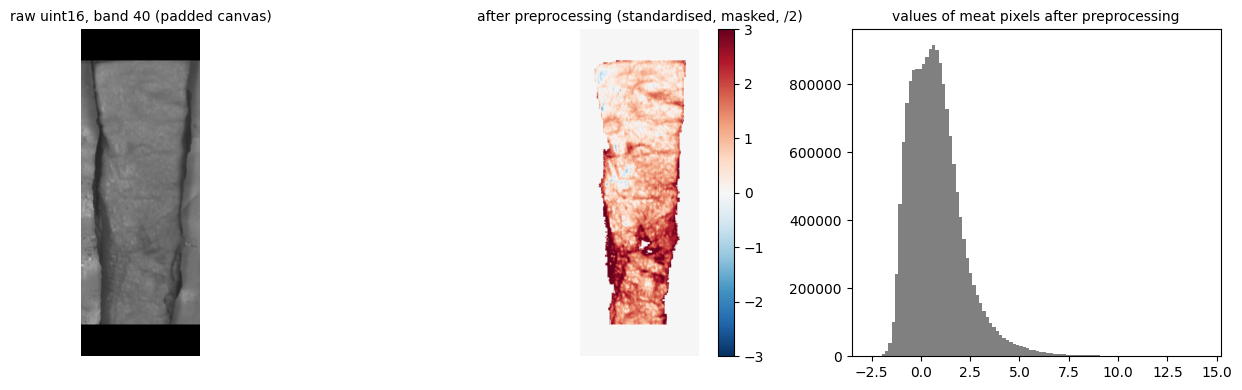

In [33]:
class ImagePreprocessor(nn.Module):
    def __init__(self, downsample_factor=2, pseudo_absorbance=True, eps=1e-6, mean=0.0, std=1.0):
        super().__init__()
        self.downsample_factor = downsample_factor
        self.pseudo_absorbance = pseudo_absorbance
        self.eps = eps
        self.standardizer = InputStandardizer(mean, std)

    def forward(self, images, masks, biases, scales):
        out = []
        for i in range(images.shape[0]):                       # one slice at a time
            img = images[i].float() / scales[i] + biases[i]    # 1. dequantise
            if self.pseudo_absorbance:
                img = -torch.log10(img.clamp(min=self.eps))    # 2. pseudo-absorbance
            img = self.standardizer(img)                       # 3. standardise
            img = img * masks[i].float()                       # 4. mask
            f = self.downsample_factor
            if f > 1:                                          # 5. area downsampling
                img = F.interpolate(img[None], size=(img.shape[-2] // f, img.shape[-1] // f), mode='area')[0]
            out.append(img)
        return torch.stack(out)                                # (S, C, H/f, W/f)


prep = ImagePreprocessor(2, mean=SPECTRA_MEAN, std=SPECTRA_STD)
with torch.no_grad():
    example_prep = prep(*example_inputs)
print('preprocessed belly:', tuple(example_prep.shape), example_prep.dtype)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(example_inputs[0][0, 40].numpy(), cmap='gray')
axes[0].set_title('raw uint16, band 40 (padded canvas)')
im = axes[1].imshow(example_prep[0, 40].numpy(), cmap='RdBu_r', vmin=-3, vmax=3)
axes[1].set_title('after preprocessing (standardised, masked, /2)')
fig.colorbar(im, ax=axes[1])
vals = example_prep[0][:, example_prep[0, 0] != 0].numpy().ravel()
axes[2].hist(vals, bins=100, color='gray')
axes[2].set_title('values of meat pixels after preprocessing')
for a in axes[:2]:
    a.axis('off')
plt.tight_layout()
plt.show()

### 8.4) A 3D convolution as spectral front-end

Before the image enters the 2D network, it passes through a small layer with a big idea: a 3D convolution that treats the spectral axis as a third spatial axis. The trick, implemented in `Conv3Don2D`, is a reshape:

$$(S, C, H, W) \;\rightarrow\; (S, 1, C, H, W) \;\xrightarrow{\text{Conv3d}}\; (S, 1, C-6, H', W') \;\rightarrow\; (S, C-6, H', W').$$

The kernel has size (7, 3, 3): 7 neighbouring bands and 3 x 3 neighbouring pixels. There is only one such kernel (63 weights and a bias), and it slides over all band positions. With a depth of 7 the kernel can represent, for example, a Savitzky-Golay filter with a window of seven bands, so the network can learn its own smoothing or derivative preprocessing, while also averaging a little spatially. Without padding ('valid' convolution), 62 bands become 62 - 7 + 1 = 56 output bands. A stride of 2 in height and width halves the image once more.

`CompoundModel` chains models: the output of the first is the input of the second. Here it glues the 3D front-end to the 2D backbone.

In [34]:
class Conv3Don2D(nn.Module):
    '''A 3D convolution applied to a (B, C, H, W) image by treating the C bands as depth.'''

    def __init__(self, in_channels, num_filters, kernel_size, normalization):
        super().__init__()
        bias = normalization is None
        self.conv = nn.Conv3d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size,
                              stride=(1, 2, 2), padding='valid', bias=bias)
        self.num_filters = num_filters
        self.normalization = normalization
        if normalization == 'bn':
            self.norm_layer = nn.BatchNorm3d(num_filters, momentum=0.01)
        elif normalization == 'ln':
            self.norm_layer = nn.Sequential(Permute((0, 2, 3, 4, 1)), nn.LayerNorm(num_filters), Permute((0, 4, 1, 2, 3)))
        else:
            self.norm_layer = nn.Identity()
        ## Number of 2D channels after flattening (filters x remaining bands)
        self.out_channels = num_filters * (in_channels - kernel_size[0] + 1)
        nn.init.kaiming_normal_(self.conv.weight)
        if self.conv.bias is not None:
            nn.init.constant_(self.conv.bias, 0)

    def forward(self, x):
        x = x.view(-1, 1, x.size(-3), x.size(-2), x.size(-1))           # (B, 1, C, H, W)
        x = self.norm_layer(self.conv(x))                               # (B, F, C-k+1, H', W')
        return x.view(-1, self.out_channels, x.size(-2), x.size(-1))     # (B, F*(C-k+1), H', W')


class CompoundModel(nn.Module):
    '''Apply several models one after the other.'''

    def __init__(self, *models):
        super().__init__()
        self.models = nn.ModuleList(models)

    def forward(self, x):
        for model in self.models:
            x = model(x)
        return x


def conv3don2d_spatial_out(h, w, kernel_hw=(3, 3), stride_hw=(2, 2)):
    '''Spatial output size of Conv3Don2D (valid padding, stride 2).'''
    return (h - kernel_hw[0]) // stride_hw[0] + 1, (w - kernel_hw[1]) // stride_hw[1] + 1


front = Conv3Don2D(INPUT_CHANNELS, num_filters=1, kernel_size=(7, 3, 3), normalization=None)
with torch.no_grad():
    print('input of Conv3Don2D :', tuple(example_prep.shape))
    print('output of Conv3Don2D:', tuple(front(example_prep).shape))
print('trainable parameters of the front-end:', count_parameters(front))

input of Conv3Don2D : (5, 62, 1238, 450)
output of Conv3Don2D: (5, 56, 618, 224)
trainable parameters of the front-end: 64


### 8.5) From slice predictions to one belly prediction

The backbone (2D ResNet or ViT) maps every slice to one number. `BellyVisionRegressor` combines them into one belly prediction with a weighted mean. The weight of slice $s$ is its number of meat pixels:
$$\hat{y}_{belly} = \sum_{s=1}^{S} w_s\,\hat{y}_s, \qquad w_s = \frac{\sum_{h,w} M_{s,h,w}}{\sum_{s'}\sum_{h,w} M_{s',h,w}}.$$

A slice with more meat contributes more, mirroring how the mean spectrum gave every meat pixel the same weight. The loss compares this single belly prediction with the belly reference, and gradients flow back into every slice. As before, an `OutputDestandardizer` maps the result back to percent. Since the weights sum to one, de-standardising once after the weighted mean gives the same result as de-standardising every slice.

In [35]:
class BellyVisionRegressor(nn.Module):
    '''preprocessor -> per-slice backbone -> mask-pixel-count weighted mean -> de-standardisation.'''

    def __init__(self, preprocessor, backbone, out_mean=0.0, out_std=1.0):
        super().__init__()
        self.preprocessor = preprocessor
        self.backbone = backbone
        self.destandardizer = OutputDestandardizer(out_mean, out_std)

    def forward(self, inputs):
        images, masks, biases, scales = inputs
        imgs = self.preprocessor(images, masks, biases, scales)        # (S, C, h, w)
        slice_preds = self.backbone(imgs)                               # (S, 1)
        weights = masks.float().sum(dim=(1, 2, 3))                      # (S,) meat pixels per slice
        weights = weights / weights.sum()
        belly_pred = (weights.view(-1, 1) * slice_preds).sum(dim=0, keepdim=True)   # (1, 1)
        return self.destandardizer(belly_pred)

## 9) The 2D ResNet

### 9.1) Build the model

The 2D ResNet-18 is the same code as the 1D version in section 7, with `dim=2`: kernels become 3 x 3 and 7 x 7 squares that slide over the image. The 56 channels coming out of the 3D front-end play the role that red, green and blue play in an ordinary photograph. The full model is

`BellyVisionRegressor( ImagePreprocessor -> CompoundModel( Conv3Don2D -> ResNet-18 (2D) ) -> weighted mean -> OutputDestandardizer )`

The global average pooling at the end of the ResNet is worth a moment of thought: it averages features over the whole slice, so the network is free to decide which regions matter, but in the end every location contributes to the same average, a learned cousin of the mean spectrum.

In [36]:
DOWNSAMPLE_FACTOR = 2
CONV3D_KERNEL = (7, 3, 3)    # (bands, height, width)
CONV3D_FILTERS = 1


def build_resnet2d():
    compression = Conv3Don2D(INPUT_CHANNELS, CONV3D_FILTERS, CONV3D_KERNEL, normalization=None)
    resnet = resnet18(input_channels=compression.out_channels, dim=2, num_classes=1, normalization=None)
    backbone = CompoundModel(compression, resnet)
    preprocessor = ImagePreprocessor(DOWNSAMPLE_FACTOR, mean=SPECTRA_MEAN, std=SPECTRA_STD)
    return BellyVisionRegressor(preprocessor, backbone, out_mean=TARGET_MEAN, out_std=TARGET_STD)


resnet2d = build_resnet2d()
## One slice is enough to follow the shapes (and saves memory); a full belly has the same shapes with S = 5
example_slice = tuple(t[:1] for t in example_inputs)
display(trace_shapes(resnet2d, example_slice, max_depth=4, device=DEVICE))
del resnet2d
free_memory()

Final output shape: (1, 1) | trainable parameters: 11,338,497


,module,type,output shape (first call),parameters,calls
0,preprocessor.standardizer,InputStandardizer,"(62, 2477, 900)",0,1
1,preprocessor,ImagePreprocessor,"(1, 62, 1238, 450)",0,1
2,backbone.models.0.conv,Conv3d,"(1, 1, 56, 618, 224)",64,1
3,backbone.models.0.norm_layer,Identity,"(1, 1, 56, 618, 224)",0,1
4,backbone.models.0,Conv3Don2D,"(1, 56, 618, 224)",64,1
5,backbone.models.1.conv1,Conv2d,"(1, 64, 309, 112)",175680,1
6,backbone.models.1.bn1,Identity,"(1, 64, 309, 112)",0,1
7,backbone.models.1.relu,ReLU,"(1, 64, 309, 112)",0,1
8,backbone.models.1.maxpool,MaxPool2d,"(1, 64, 155, 56)",0,1
9,backbone.models.1.layer1,Sequential,"(1, 64, 155, 56)",147712,1


### 9.2) How the 2D ResNet was trained, and a demonstration

With the full dataset, training is belly-level: one belly is one optimizer step, about 97 steps per epoch. The pre-trained weights were produced with the `train_regressor` function of section 5.3 and these settings:

```python
train_regressor(build_resnet2d(),
                train_loader=image_loader(TRAIN_SPLITS, augment=True, shuffle=True),
                val_loader=image_loader(VAL_SPLITS, augment=False, shuffle=False),
                train_eval_loader=image_loader(TRAIN_SPLITS, augment=False, shuffle=False),
                save_dir=RUN_DIR / 'resnet2d', init_lr=1e-3, weight_decay=1e-4,
                max_epochs=250, burn_in_epochs=30, reduce_lr_patience=10, early_stop_patience=30)
```

That run reads about 100 GB of images per epoch and needs many GPU hours, so we do not repeat it here. Instead, the demonstration below takes a fresh, untrained model and performs a few optimizer steps on one example belly, with random flips switched on. You will see every ingredient of a real training step at work: the forward pass through all slices, the weighted belly prediction, the squared error, the backward pass and the AdamW update.

Two remarks to discuss:

- The example bellies belong to the test set. Training on them for real would be cheating, since the test set must stay unseen. Here it is only a demonstration, and the demonstration model is thrown away afterwards.
- The error will drop quickly, because the model only needs to fit one number. That is memorisation, not learning. With one sample there is nothing to generalise from.
- The first steps can jump wildly (a prediction of thousands of percent after one update is not unusual). A freshly initialised network without normalisation layers is far from calibrated, and one large gradient step overshoots. This is exactly why real training uses many samples per epoch, a validation set and a schedule that lowers the learning rate.

On a GPU each step takes about a second, on a CPU considerably longer (reduce `DEMO_STEPS` in section 0 if needed).

step  1 | reference  25.48 | prediction   119.63 | squared error    8863.78 | 4.4 s
step  2 | reference  25.48 | prediction -22113.38 | squared error 490128992.00 | 3.4 s
step  3 | reference  25.48 | prediction  -134.71 | squared error   25660.83 | 3.6 s
step  4 | reference  25.48 | prediction     3.85 | squared error     467.92 | 3.5 s
step  5 | reference  25.48 | prediction    24.72 | squared error       0.57 | 3.4 s
step  6 | reference  25.48 | prediction    33.27 | squared error      60.72 | 3.4 s
step  7 | reference  25.48 | prediction    32.39 | squared error      47.81 | 2.7 s
step  8 | reference  25.48 | prediction    27.37 | squared error       3.58 | 2.4 s


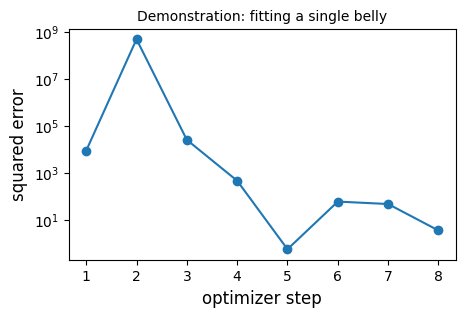

In [37]:
def demo_training(build_fn, belly_id, steps=DEMO_STEPS, lr=1e-3, weight_decay=1e-4):
    ## A few AdamW steps on one belly, to show a training step at work. The model is discarded afterwards.
    reproducible_comp()
    model = build_fn().to(DEVICE)
    optimizer = make_adamw(model, lr, weight_decay)
    dataset = BellyImageDataset(ALL_SPLITS, IMAGE_BASE, IMAGE_TARGET_SIZE, augment=True)
    idx = [m for m, _ in dataset.bellies].index(belly_id)
    losses = []
    for step in range(1, steps + 1):
        t0 = time.time()
        inputs, refs, _ = belly_collate([dataset[idx]])   # a freshly flipped version of the belly
        inputs, refs = to_device(inputs, DEVICE), refs.to(DEVICE)
        model.train()
        optimizer.zero_grad()
        pred = model(inputs)                                # forward: all slices -> one belly prediction
        loss = ((refs - pred) ** 2).sum()                   # squared error of this belly
        loss.backward()                                     # gradients for every weight
        optimizer.step()                                    # AdamW update
        losses.append(loss.item())
        print(f'step {step:2d} | reference {refs.item():6.2f} | prediction {pred.item():8.2f} | '
              f'squared error {loss.item():10.2f} | {time.time() - t0:.1f} s')
    plt.figure(figsize=(5, 3))
    plt.plot(range(1, steps + 1), losses, 'o-')
    plt.yscale('log')
    plt.xlabel('optimizer step')
    plt.ylabel('squared error')
    plt.title('Demonstration: fitting a single belly')
    plt.show()
    del model, optimizer
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


demo_training(build_resnet2d, EXAMPLE_BELLIES[0])

### GPU CHECKPOINT: 2D ResNet

This is the main interruption point for the image models. If your GPU time is over, switch to a CPU runtime, rerun sections 0 to 5, the definition cells of sections 7 (the ResNet code), 8 and 9.1, and continue here.

The cell loads the pre-trained weights and predicts the two example bellies. The table opens up each belly prediction: the prediction for every slice, its weight (its share of the meat pixels) and the weighted mean. Which slices pull the belly prediction up or down, and how far apart are the slices of one belly?

In [38]:
def predict_bellies(model, loader):
    '''One pass over the bellies. Returns a table with the per-slice predictions, the slice weights
    (share of the meat pixels) and the weighted belly prediction, plus a results table per belly.'''
    rows, belly_rows = [], []
    model.eval()
    with torch.no_grad():
        for inputs, refs, ids in loader:
            inputs = to_device(inputs, DEVICE)
            imgs = model.preprocessor(*inputs)
            slice_preds = model.backbone(imgs).reshape(-1)                         # standardised, per slice
            w = inputs[1].float().sum(dim=(1, 2, 3))
            w = w / w.sum()                                                        # weights sum to one
            belly_pred = float(model.destandardizer((w * slice_preds).sum()))       # exactly what model(inputs) returns
            for s, (p, wi) in enumerate(zip(model.destandardizer(slice_preds).cpu().numpy(), w.cpu().numpy()), start=1):
                rows.append({'belly': ids[0], 'slice': str(s), 'prediction (%)': p, 'weight': wi})
            rows.append({'belly': ids[0], 'slice': 'weighted mean', 'prediction (%)': belly_pred,
                         'weight': 1.0, 'reference (%)': float(refs)})
            belly_rows.append({'meat_id': int(ids[0]), 'true': float(refs), 'pred': belly_pred})
            del inputs, imgs
            free_memory()
    return pd.DataFrame(rows).round(3), pd.DataFrame(belly_rows)


resnet2d = load_trained_model(build_resnet2d, 'resnet2d')
table, results['2D ResNet'] = predict_bellies(resnet2d, image_loader(ALL_SPLITS, augment=False, shuffle=False))
display(table)

Loaded resnet2d weights from data/end2end/resnet2d/best_weights.pt


,belly,slice,prediction (%),weight,reference (%)
0,10,1,22.958,0.183,NaN
1,10,2,19.614,0.198,NaN
2,10,3,23.452,0.203,NaN
3,10,4,36.920,0.198,NaN
4,10,5,39.540,0.218,NaN
5,10,weighted mean,28.770,1.000,25.48
6,70,1,18.802,0.171,NaN
7,70,2,67.426,0.199,NaN
8,70,3,46.120,0.211,NaN
9,70,4,69.371,0.210,NaN


## 10) The Vision Transformer (ViT)

### 10.1) Theory: images as sequences of patches

Convolutions see the world through a small window that grows slowly with depth. Transformers, originally built for language, take the opposite approach: from the very first layer, every element can look at every other element. The Vision Transformer (Dosovitskiy et al., 2020) applies this to images in four steps:

1. Patch embedding. The image is cut into non-overlapping patches of 32 x 32 pixels. Each patch (56 channels x 32 x 32 values) is mapped to a vector of length 192 by one shared linear map. In code this is a single convolution with kernel size = stride = 32. If the image size is not a multiple of 32, it is zero-padded at the bottom and right first, so no pixels are dropped.
2. Class token and position embedding. A learned extra vector, the CLS token, is placed in front of the sequence of patch vectors. It will collect information from all patches. Attention itself has no notion of order, so a learned position embedding is added to every token to tell the model where each patch came from.
3. Transformer blocks. Each block lets the tokens exchange information with self-attention, then processes every token with a small MLP.
4. Head. The CLS token after the last block goes through a linear layer that outputs the prediction for the slice.

Self-attention, the heart of the model. Every token vector $\mathbf{x}_i$ is projected into a query $\mathbf{q}_i$, a key $\mathbf{k}_i$ and a value $\mathbf{v}_i$. Token $i$ then forms a weighted average of all values, with weights that measure how well its query matches each key:
$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V.$$
Multi-head attention runs this several times in parallel (here 3 heads of size 64) so that different heads can specialise.

The transformer block uses the pre-norm layout with two residual connections, just like the ResNet:
$$\mathbf{x} \leftarrow \mathbf{x} + \mathrm{MHA}(\mathrm{LN}(\mathbf{x})), \qquad \mathbf{x} \leftarrow \mathbf{x} + \mathrm{MLP}(\mathrm{LN}(\mathbf{x})).$$

Our ViT is deliberately small (2 blocks, 3 heads, embedding size 192). Transformers have weaker built-in assumptions than CNNs, and with fewer than 100 training bellies they can easily overfit.

### 10.2) The building blocks

We implement attention from scratch (following the PyTorch tutorial on multi-head attention), which makes it a perfect teaching example. One detail: the query, key and value projections are packed into one linear layer (`packed_proj`) that outputs three times the embedding size, and the result is split into three. The actual attention computation is delegated to `F.scaled_dot_product_attention`, which implements the formula above efficiently.

In [39]:
class MultiHeadAttention(nn.Module):
    '''Multi-head attention with packed Q/K/V projection (self-attention case).'''

    def __init__(self, E_q, E_k, E_v, E_total, nheads, dropout=0.0, bias=True):
        super().__init__()
        self.nheads = nheads
        self.dropout = dropout
        self._qkv_same_embed_dim = E_q == E_k and E_q == E_v
        if self._qkv_same_embed_dim:
            self.packed_proj = nn.Linear(E_q, E_total * 3, bias=bias)
        else:
            self.q_proj = nn.Linear(E_q, E_total, bias=bias)
            self.k_proj = nn.Linear(E_k, E_total, bias=bias)
            self.v_proj = nn.Linear(E_v, E_total, bias=bias)
        self.out_proj = nn.Linear(E_total, E_q, bias=bias)
        assert E_total % nheads == 0, 'Embedding dim is not divisible by nheads'
        self.E_head = E_total // nheads
        self.bias = bias

    def forward(self, query, key, value):
        ## Step 1: input projection (for self-attention query, key and value are the same tensor)
        if self._qkv_same_embed_dim and query is key and key is value:
            query, key, value = torch.chunk(self.packed_proj(query), 3, dim=-1)
        elif self._qkv_same_embed_dim:
            q_w, k_w, v_w = torch.chunk(self.packed_proj.weight, 3, dim=0)
            q_b, k_b, v_b = torch.chunk(self.packed_proj.bias, 3, dim=0) if self.bias else (None, None, None)
            query, key, value = F.linear(query, q_w, q_b), F.linear(key, k_w, k_b), F.linear(value, v_w, v_b)
        else:
            query, key, value = self.q_proj(query), self.k_proj(key), self.v_proj(value)
        ## Step 2: split the heads: (N, L, E_total) -> (N, nheads, L, E_head)
        query = query.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)
        key = key.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)
        value = value.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)
        ## Step 3: softmax(Q K^T / sqrt(d)) V for every head
        attn = F.scaled_dot_product_attention(query, key, value, dropout_p=self.dropout if self.training else 0.0)
        ## Step 4: merge the heads and project back: (N, nheads, L, E_head) -> (N, L, E_total) -> (N, L, E_q)
        return self.out_proj(attn.transpose(1, 2).flatten(-2))


class FeedForward(nn.Module):
    '''The per-token MLP of a transformer block: Linear(E, 4E) -> GELU -> Linear(4E, E).'''

    def __init__(self, embedding_dim, dropout_rate):
        super().__init__()
        self.hidden_dim = embedding_dim * 4
        self.mlp = nn.Sequential(nn.Linear(embedding_dim, self.hidden_dim), nn.GELU(),
                                 nn.Linear(self.hidden_dim, embedding_dim))
        self.dropout = nn.Dropout(dropout_rate)
        for i in (0, 2):
            nn.init.xavier_normal_(self.mlp[i].weight)
            nn.init.zeros_(self.mlp[i].bias)

    def forward(self, x):
        return self.dropout(self.mlp(x))


class TransformerBlock(nn.Module):
    '''Pre-norm transformer block: x + MHA(LN(x)), then x + FF(LN(x)).'''

    def __init__(self, embedding_dim, num_attention_heads, dropout_rate, normalization='ln', layernorm_eps=1e-5):
        super().__init__()
        self.attention = MultiHeadAttention(embedding_dim, embedding_dim, embedding_dim, embedding_dim,
                                            nheads=num_attention_heads, dropout=dropout_rate, bias=True)
        self.normalization = normalization
        self.ff = FeedForward(embedding_dim, dropout_rate)
        if normalization == 'ln':
            self.norm1 = nn.LayerNorm([embedding_dim], eps=layernorm_eps)
            self.norm2 = nn.LayerNorm([embedding_dim], eps=layernorm_eps)

    def forward(self, x):
        h = self.norm1(x) if self.normalization == 'ln' else x
        x = x + self.attention(h, h, h)                 # residual connection around attention
        h = self.norm2(x) if self.normalization == 'ln' else x
        return x + self.ff(h)                           # residual connection around the MLP

Now the complete ViT: patch embedding, CLS token, position embedding, a stack of transformer blocks and the regression head. The function `vit_shape` computes which image size the ViT receives after preprocessing and the Conv3D front-end, so that the patch grid and the position embedding get the right size.

In [40]:
class ViT(nn.Module):
    '''A small ViT that maps a fixed-size image to num_outputs scalars via the CLS token.'''

    def __init__(self, in_channels=62, img_size=(1238, 450), patch_size=32, embed_dim=192, depth=2,
                 num_heads=3, dropout=0.0, num_outputs=1):
        super().__init__()
        self.patch_size = patch_size
        ## Patch embedding: one strided convolution = one shared linear map per patch
        self.embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        grid_h = math.ceil(img_size[0] / patch_size)
        grid_w = math.ceil(img_size[1] / patch_size)
        self.num_patches = grid_h * grid_w
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads, dropout, normalization='ln')
                                     for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_outputs)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        ## Zero-pad bottom and right so that H and W are multiples of the patch size
        h, w = x.shape[-2], x.shape[-1]
        pad_h = (self.patch_size - h % self.patch_size) % self.patch_size
        pad_w = (self.patch_size - w % self.patch_size) % self.patch_size
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        x = self.embed(x)                                   # (B, E, grid_h, grid_w)
        x = x.flatten(2).transpose(1, 2)                    # (B, num_patches, E): a sequence of tokens
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls, x), dim=1)                      # (B, num_patches + 1, E)
        x = self.dropout(x + self.pos_embed)                # add the position information
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x[:, 0])                           # read out the CLS token


PATCH_SIZE, EMBED_DIM, DEPTH, NUM_HEADS = 32, 192, 2, 3


def vit_shape():
    '''Channels and (H, W) that the ViT sees after downsampling and the Conv3D front-end.'''
    prep_hw = (IMAGE_TARGET_SIZE[0] // DOWNSAMPLE_FACTOR, IMAGE_TARGET_SIZE[1] // DOWNSAMPLE_FACTOR)
    channels = CONV3D_FILTERS * (INPUT_CHANNELS - CONV3D_KERNEL[0] + 1)
    return channels, conv3don2d_spatial_out(*prep_hw, kernel_hw=CONV3D_KERNEL[1:])


def build_vit():
    _, img_size = vit_shape()
    compression = Conv3Don2D(INPUT_CHANNELS, CONV3D_FILTERS, CONV3D_KERNEL, normalization=None)
    vit = ViT(in_channels=compression.out_channels, img_size=img_size, patch_size=PATCH_SIZE,
              embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS, dropout=0.0, num_outputs=1)
    backbone = CompoundModel(compression, vit)
    preprocessor = ImagePreprocessor(DOWNSAMPLE_FACTOR, mean=SPECTRA_MEAN, std=SPECTRA_STD)
    return BellyVisionRegressor(preprocessor, backbone, out_mean=TARGET_MEAN, out_std=TARGET_STD)


channels, img_size = vit_shape()
vit_model = build_vit()
grid = vit_model.backbone.models[1]
print(f'ViT input: {channels} channels at {img_size}; patch grid {math.ceil(img_size[0] / PATCH_SIZE)} x '
      f'{math.ceil(img_size[1] / PATCH_SIZE)} = {grid.num_patches} patches (+1 CLS token)')
display(trace_shapes(vit_model, example_slice, max_depth=4, device=DEVICE))
del vit_model
free_memory()

ViT input: 56 channels at (618, 224); patch grid 20 x 7 = 140 patches (+1 CLS token)
Final output shape: (1, 1) | trainable parameters: 11,927,873


,module,type,output shape (first call),parameters,calls
0,preprocessor.standardizer,InputStandardizer,"(62, 2477, 900)",0,1
1,preprocessor,ImagePreprocessor,"(1, 62, 1238, 450)",0,1
2,backbone.models.0.conv,Conv3d,"(1, 1, 56, 618, 224)",64,1
3,backbone.models.0.norm_layer,Identity,"(1, 1, 56, 618, 224)",0,1
4,backbone.models.0,Conv3Don2D,"(1, 56, 618, 224)",64,1
5,backbone.models.1.embed,Conv2d,"(1, 192, 20, 7)",11010240,1
6,backbone.models.1.dropout,Dropout,"(1, 141, 192)",0,1
7,backbone.models.1.norm,LayerNorm,"(1, 141, 192)",384,1
8,backbone.models.1.head,Linear,"(1, 1)",193,1
9,backbone.models.1,ViT,"(1, 1)",11927809,1


Compare the parameter count with the 2D ResNet: both have roughly 11 to 12 million parameters, but they are distributed very differently. In the ViT almost all of them sit in the patch embedding (56 x 32 x 32 x 192, about 11 million weights), while the two transformer blocks together have less than one million. The position embedding has one vector per patch position, which is why the image size must be identical at training and prediction time.

### 10.3) Training the ViT: a demonstration

The pre-trained ViT was trained with the same `train_regressor` call and settings as the 2D ResNet (section 9.2), only with `build_vit()`. Here we again run a short demonstration on one example belly. Compare with the 2D ResNet demonstration: does the ViT reach a small error in as few steps?

step  1 | reference  25.48 | prediction    32.28 | squared error      46.26 | 3.3 s
step  2 | reference  25.48 | prediction   -10.74 | squared error    1312.16 | 2.6 s
step  3 | reference  25.48 | prediction    79.50 | squared error    2918.67 | 2.5 s
step  4 | reference  25.48 | prediction    56.21 | squared error     944.57 | 2.4 s
step  5 | reference  25.48 | prediction    36.39 | squared error     118.97 | 2.1 s
step  6 | reference  25.48 | prediction    22.87 | squared error       6.82 | 2.5 s
step  7 | reference  25.48 | prediction    14.83 | squared error     113.51 | 2.8 s
step  8 | reference  25.48 | prediction    11.08 | squared error     207.26 | 2.3 s


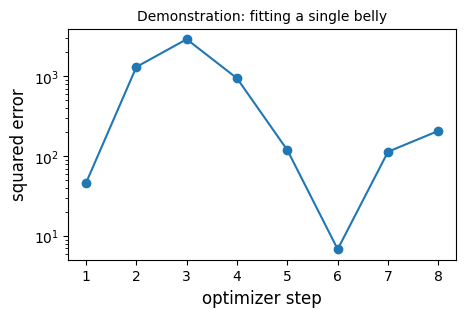

In [41]:
demo_training(build_vit, EXAMPLE_BELLIES[0])

### GPU CHECKPOINT: ViT

Load the pre-trained ViT and predict the two example bellies. This cell, and everything after it, runs on a CPU.

In [42]:
vit_model = load_trained_model(build_vit, 'vit')
table, results['ViT'] = predict_bellies(vit_model, image_loader(ALL_SPLITS, augment=False, shuffle=False))
display(table)

Loaded vit weights from data/end2end/vit/best_weights.pt


,belly,slice,prediction (%),weight,reference (%)
0,10,1,35.087,0.183,NaN
1,10,2,25.933,0.198,NaN
2,10,3,22.252,0.203,NaN
3,10,4,24.205,0.198,NaN
4,10,5,25.816,0.218,NaN
5,10,weighted mean,26.488,1.000,25.48
6,70,1,58.439,0.171,NaN
7,70,2,54.689,0.199,NaN
8,70,3,59.267,0.211,NaN
9,70,4,56.505,0.210,NaN


### 10.4) Where does the ViT look?

The attention weights of the CLS token in the last block tell us how much each patch contributed to the information gathered by the CLS token. Our attention module does not return these weights (it calls the fused `scaled_dot_product_attention`), but we can recompute them: we capture the normalised input of the last block with a hook and apply the packed projection and the softmax ourselves. The map below averages the three heads.

Attention maps are a popular but imperfect explanation tool: they show where information was gathered, not why, and they ignore everything that happens after the attention step. 

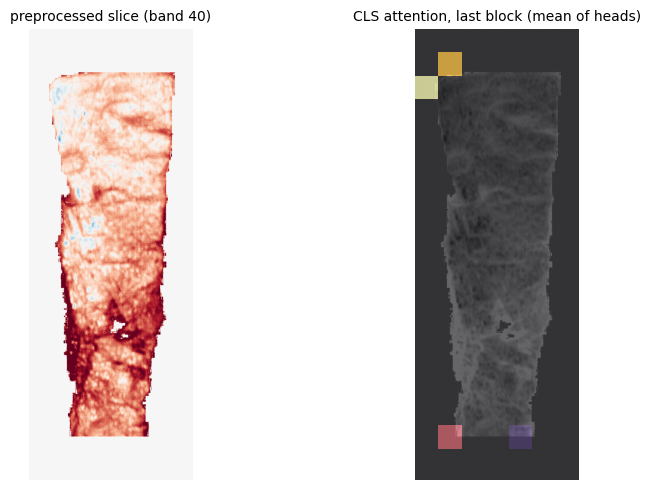

In [43]:
def cls_attention_map(model, inputs, slice_idx=0):
    vit = model.backbone.models[1]
    last = vit.blocks[-1]
    captured = {}
    hook = last.norm1.register_forward_hook(lambda m, i, o: captured.__setitem__('h', o))
    model.eval()
    device = next(model.parameters()).device          # run on whatever device the model is on
    with torch.no_grad():
        imgs = model.preprocessor(*to_device(inputs, device))[slice_idx:slice_idx + 1]
        feats = model.backbone.models[0](imgs)          # output of the Conv3D front-end
        vit(feats)
    hook.remove()
    att = last.attention
    with torch.no_grad():
        q, k, _ = torch.chunk(att.packed_proj(captured['h']), 3, dim=-1)
        q = q.unflatten(-1, [att.nheads, att.E_head]).transpose(1, 2)
        k = k.unflatten(-1, [att.nheads, att.E_head]).transpose(1, 2)
        weights = torch.softmax(q @ k.transpose(-2, -1) / math.sqrt(att.E_head), dim=-1)   # (1, heads, L, L)
        cls_to_patches = weights[0, :, 0, 1:].mean(0)                                        # average over heads
    gh = math.ceil(feats.shape[-2] / vit.patch_size)
    gw = math.ceil(feats.shape[-1] / vit.patch_size)
    return imgs[0].cpu(), cls_to_patches.reshape(gh, gw).cpu().numpy(), feats.shape[-2:]


img, att_map, hw = cls_attention_map(vit_model, example_inputs, slice_idx=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[40].numpy(), cmap='RdBu_r', vmin=-3, vmax=3)
axes[0].set_title('preprocessed slice (band 40)')
gh, gw = att_map.shape
axes[1].imshow(img[40].numpy(), cmap='gray', vmin=-3, vmax=3)
## One patch covers PATCH_SIZE pixels after the stride-2 Conv3D, i.e. about 2 * PATCH_SIZE preprocessed pixels
axes[1].imshow(att_map, cmap='inferno', alpha=0.6, extent=(0, gw * PATCH_SIZE * 2, gh * PATCH_SIZE * 2, 0))
axes[1].set_xlim(0, img.shape[-1])
axes[1].set_ylim(img.shape[-2], 0)
axes[1].set_title('CLS attention, last block (mean of heads)')
for a in axes:
    a.axis('off')
plt.tight_layout()
plt.show()

## 11) Comparing the five models

Time to put everything side by side. We have two kinds of results:

- the three spectral models were evaluated on all 60 test bellies, which gives meaningful RMSE and $R^2$ values;
- all five models predicted the two example bellies. Two bellies are far too few for statistics, but they allow a direct, belly-by-belly comparison, including the image models.

For the RMSE of the image models on the full test set, the reference study is the place to look: with the full data, the image-based models end up in the same range as the spectral ones.

Spectral models on the full test set


,test bellies,RMSE,R2
model,,,
PLS,60,5.904,0.799
MLP,60,5.650,0.816
1D ResNet,60,6.765,0.736


All models on the example bellies (predicted fat, %)


,reference,PLS,MLP,1D ResNet,2D ResNet,ViT
meat_id,,,,,,
10,25.48,27.39,24.160000,24.870001,28.77,26.49
70,62.78,57.83,62.290001,68.980003,55.27,56.76


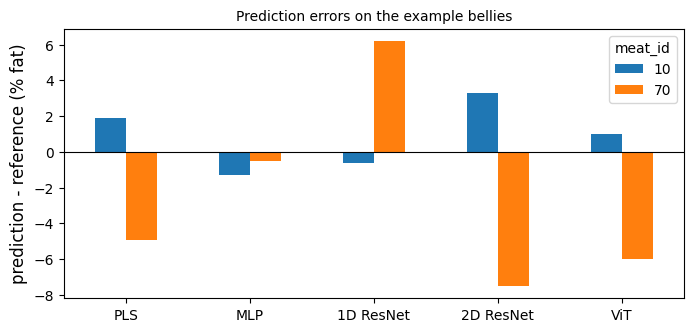

In [44]:
spectral = [name for name in ['PLS', 'MLP', '1D ResNet'] if name in results]
summary = pd.DataFrame([{'model': name, 'test bellies': len(results[name]),
                         'RMSE': rmse(results[name].pred, results[name].true),
                         'R2': r2_score(results[name].pred, results[name].true)} for name in spectral]).set_index('model')
print('Spectral models on the full test set')
display(summary.round(3))

## All five models on the example bellies, one column per model
table = pd.DataFrame({'reference': results[spectral[0]].set_index('meat_id').true}).loc[EXAMPLE_BELLIES]
for name, df in results.items():
    table[name] = df.set_index('meat_id').pred.reindex(EXAMPLE_BELLIES)
table.index.name = 'meat_id'
print('All models on the example bellies (predicted fat, %)')
display(table.round(2))

errors = table.drop(columns='reference').sub(table['reference'], axis=0)
errors.T.plot.bar(figsize=(8, 3.5), rot=0)
plt.axhline(0, color='k', lw=0.8)
plt.ylabel('prediction - reference (% fat)')
plt.title('Prediction errors on the example bellies')
plt.legend(title='meat_id')
plt.show()

Finally, the classical scatter plots of the spectral models on all test bellies, with the two example bellies circled in red.

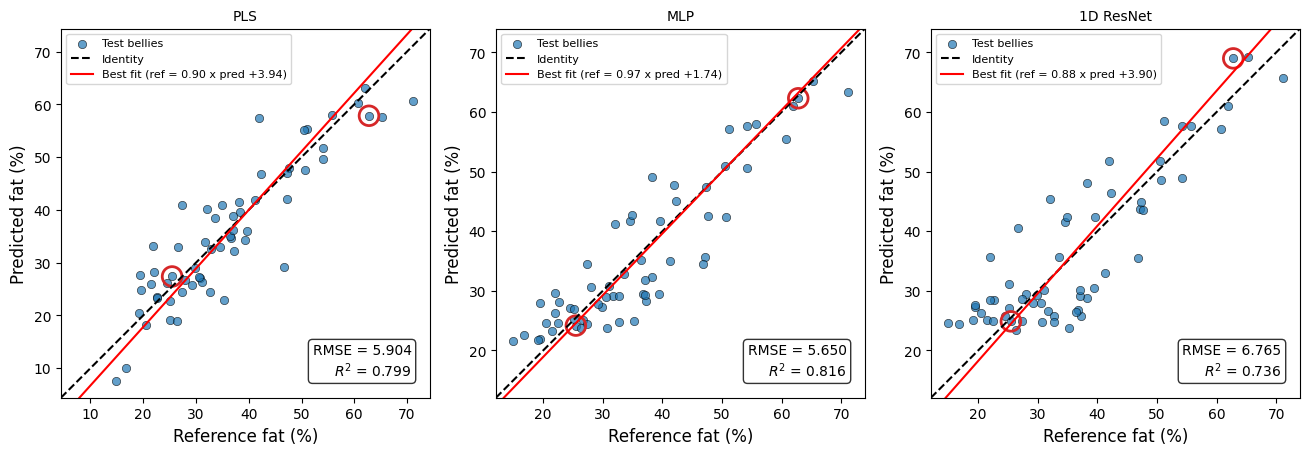

In [45]:
## Scatter plots of the spectral models on the full test set, with the example bellies circled
fig, axes = plt.subplots(1, len(spectral), figsize=(4.4 * len(spectral), 4.6))
for ax, name in zip(np.atleast_1d(axes), spectral):
    df = results[name]
    prediction_scatter_plot(df.pred.values, df.true.values, name, ax=ax)
    ex = df[df.meat_id.isin(EXAMPLE_BELLIES)]
    ax.scatter(ex.true, ex.pred, s=200, facecolors='none', edgecolors='tab:red', linewidths=2)
plt.tight_layout()
plt.show()